# Cross-cell-line Factor Comparison

Each cell line was analyzed separately (`analysis_<line>.ipynb`): a few protein programs (latent protein-factors, each a weighted combination of the 22 proteins) summarize its average protein levels per drug and cell-cycle phase, together with how strongly each drug and phase activates each factor. This notebook asks which factors and drug responses are shared across the 8 cell lines.

Notation:
- Cell lines $\ell$ ($L = 8$), treatments $t$ (8), phases $j \in \{\mathrm{G1}, \mathrm{G2}, \mathrm{S}\}$ ($c = 3$), proteins $r$ ($p = 22$), latent protein-factors $f$ ($p_F = 4$).
- Per cell line: $\mathcal{X}^{(\ell)} \approx \mathcal{G}^{(\ell)} \times_1 T^{(\ell)} \times_2 C^{(\ell)} \times_3 P^{(\ell)}$, with protein loadings $P^{(\ell)} \in \mathbb{R}^{p \times p_F}$.
- Factor activity: $\mathcal{F}^{(\ell)} = \mathcal{G}^{(\ell)} \times_1 T^{(\ell)} \times_2 C^{(\ell)} \in \mathbb{R}^{8 \times c \times p_F}$; phase average $\bar{\mathcal{F}}^{(\ell)}_{tf} = \frac{1}{c} \sum_j \mathcal{F}^{(\ell)}_{tjf}$.

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from carve import CARVE, SpectralClustering

from cc_tensor import sign_align_protein_factors, cross_cellline_protein_factors, cross_cellline_treatment_factors, cross_cellline_protein_factors_by_treatment, cross_cellline_phase_profiles, cross_cellline_protein_influence
from cc_tensor_viz import cross_cellline_embedding, cross_cellline_clustermap, cross_cellline_loading_violins, cross_cellline_treatment_violins, cross_cellline_cluster_violins, cross_cellline_cluster_heatmap

/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load results:

Load the factors fitted in each per-cell-line notebook.

1. For each $\ell$: load the fitted `CCTensor` from `results/cct_<line>.pkl`.

In [2]:
CELL_LINES = ["134", "231", "44PE", "453", "BCK4", "MCF10A", "MCF7", "T47D"]

cct_dict = {}
for name in CELL_LINES:
    with open(f"results/cct_{name}.pkl", "rb") as f:
        cct_dict[name] = pickle.load(f)


### 1.1 Sign alignment of the protein factors:

A factor and its mirror image (all protein weights and activities negated) describe the same biology, and each cell line's fit picks one of the two arbitrarily. We flip factors where needed so that a factor points the same way in every cell line; each line's fitted data are unchanged.

For each factor $f$:

1. $V_f \leftarrow [P^{(1)}_{:,f}, \dots, P^{(L)}_{:,f}] \in \mathbb{R}^{p \times L}$.
2. $\mathbf{v}_f \leftarrow$ leading left singular vector of $V_f$, oriented so that $\sum_\ell \mathbf{v}_f^\top P^{(\ell)}_{:,f} > 0$.
3. $s_{\ell f} \leftarrow \operatorname{sign}(\mathbf{v}_f^\top P^{(\ell)}_{:,f})$.
4. $P^{(\ell)}_{:,f} \leftarrow s_{\ell f} P^{(\ell)}_{:,f}$ and $\mathcal{G}^{(\ell)}_{:,:,f} \leftarrow s_{\ell f}\, \mathcal{G}^{(\ell)}_{:,:,f}$; $\hat{\mathcal{X}}^{(\ell)}$ is unchanged.

Table: $s_{\ell f}$ ($-1$ = flipped). Alignment fixes signs only; whether factor $f$ is the same program in every line is shown by the clustermap in 2.3.

In [3]:
cct_dict, flips = sign_align_protein_factors(cct_dict)
flips

,Factor 1,Factor 2,Factor 3,Factor 4
134,1,1,1,1
231,1,1,-1,1
44PE,1,1,1,-1
453,1,1,1,-1
BCK4,1,1,-1,1
MCF10A,1,1,1,1
MCF7,1,1,-1,1
T47D,1,1,1,1


## 2. Protein factors across cell lines:

Each factor is a set of 22 protein weights: proteins with the same sign move together when the factor is active, proteins with opposite signs move in opposite directions. We collect these weights from all cell lines to compare factors between lines.

1. For each $(\ell, f)$: row $\mathbf{x}_{\ell f} \leftarrow P^{(\ell)}_{:,f} \in \mathbb{R}^{p}$.
2. $X_P \leftarrow$ all rows, $X_P \in \mathbb{R}^{L p_F \times p}$ ($32 \times 22$).

In [4]:
protein_factor_df = cross_cellline_protein_factors(cct_dict)
print(f"Protein factor matrix: {protein_factor_df.shape}")
protein_factor_df.head(8)

Protein factor matrix: (32, 22)


Ki67  nuclear_area       p16      CDH1     cycA2  \
cell_line factor                                                           
134       Factor 1  0.309054      0.260058  0.154763  0.187813  0.313548   
          Factor 2 -0.110047     -0.082420  0.269523  0.044868 -0.071779   
          Factor 3  0.064151     -0.107542 -0.031495 -0.291430 -0.075623   
          Factor 4  0.025851      0.178994  0.173912  0.124937  0.041741   
231       Factor 1  0.166754      0.213476  0.242238  0.101870  0.283000   
          Factor 2 -0.358488     -0.010658  0.087476  0.055417 -0.158718   
          Factor 3 -0.077960      0.345857  0.122165 -0.498515  0.109670   
          Factor 4  0.088327     -0.143011 -0.331186  0.079764  0.070779   

                       cycE1      CDK2        RB     CycB1       p21  ...  \
cell_line factor                                                      ...   
134       Factor 1  0.011401  0.294478  0.263454  0.289473  0.124638  ...   
          Factor 2  0.360109  0.086330  0.163305 -0.073377  0.075582  ...   
          Factor 3  0.172004  0.145614  0.147249 -0.252133 -0.504886  ...   
          Factor 4  0.114970  0.001032  0.166131  0.058611 -0.130292  ...   
231       Factor 1  0.200141  0.283057  0.283315  0.159846  0.219409  ...   
          Factor 2  0.307953 -0.010055 -0.039887 -0.299900  0.068270  ...   
          Factor 3  0.044338  0.214487  0.172178 -0.163036 -0.212789  ...   
          Factor 4  0.234935  0.043985 -0.074072 -0.212884 -0.243337  ...   

                        CDK4     cycA1      PCNA       p53       p27  \
cell_line factor                                                       
134       Factor 1  0.047704  0.168426  0.244166  0.152372 -0.081468   
          Factor 2  0.344536  0.181334 -0.049968  0.030895  0.366391   
          Factor 3  0.102507  0.021735  0.365364  0.224173 -0.105640   
          Factor 4  0.300213 -0.447069 -0.115355 -0.644374 -0.071841   
231       Factor 1  0.255212  0.191378  0.251170  0.225159  0.170364   
          Factor 2  0.232973  0.177790 -0.116429 -0.066915  0.256869   
          Factor 3  0.142637 -0.323891  0.157177  0.053072 -0.328011   
          Factor 4  0.100340  0.072552  0.282800 -0.399779 -0.027228   

                       cycB2      SKP2      CDT1     cycE2   DNA_int  
cell_line factor                                                      
134       Factor 1  0.296771  0.301653 -0.128023  0.105636  0.279074  
          Factor 2 -0.067926  0.021984  0.244659  0.341412 -0.076531  
          Factor 3 -0.231503  0.170020 -0.297924  0.217011 -0.198424  
          Factor 4  0.027035  0.188062 -0.166458  0.023581 -0.190074  
231       Factor 1  0.188823  0.266094 -0.035232  0.217141  0.170020  
          Factor 2 -0.271870 -0.158580  0.292482  0.183208 -0.309509  
          Factor 3 -0.286405  0.151781  0.018180 -0.159940 -0.239003  
          Factor 4 -0.088109  0.148076 -0.442720  0.372898 -0.109075  

[8 rows x 22 columns]

### 2.1 PCA:

Each point is one factor from one cell line, placed so that factors with similar protein weights sit close together. If a factor is shared by all lines, its 8 points (one color) form a tight group.

1. $Z \leftarrow \mathrm{PCA}_2(X_P)$.
2. Scatter $Z$, one point per $(\ell, f)$: color $= f$, marker $= \ell$.

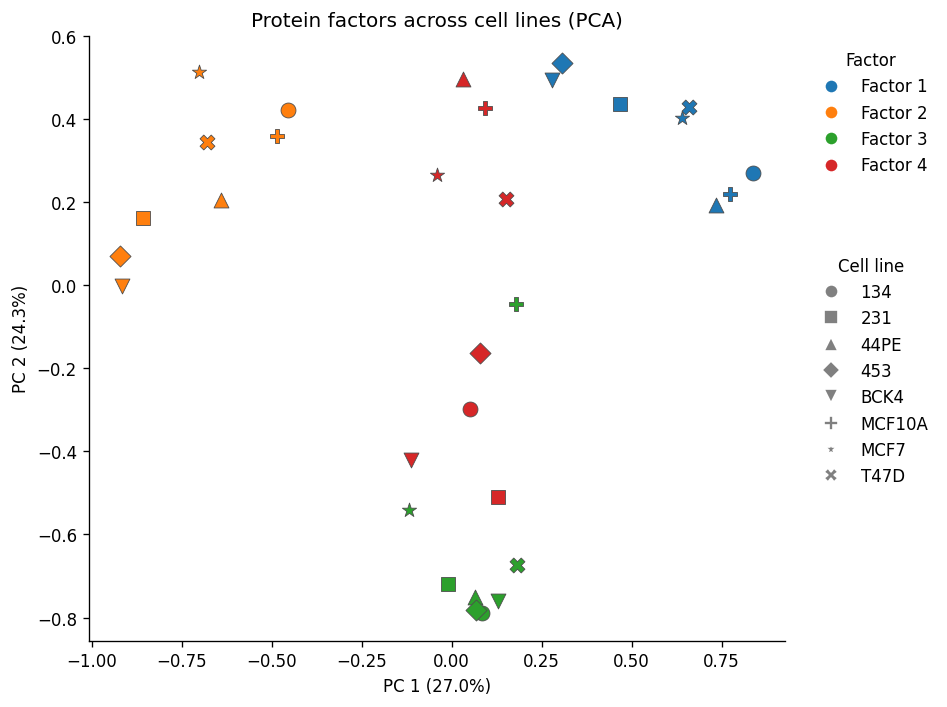

In [5]:
cross_cellline_embedding(
    protein_factor_df, method="pca",
    title="Protein factors across cell lines (PCA)"
);

### 2.2 UMAP:

The same comparison with a nonlinear map that keeps close neighbors together; tight groups are meaningful, distances between groups are not.

As 2.1 with $Z \leftarrow \mathrm{UMAP}_2(X_P)$.

/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


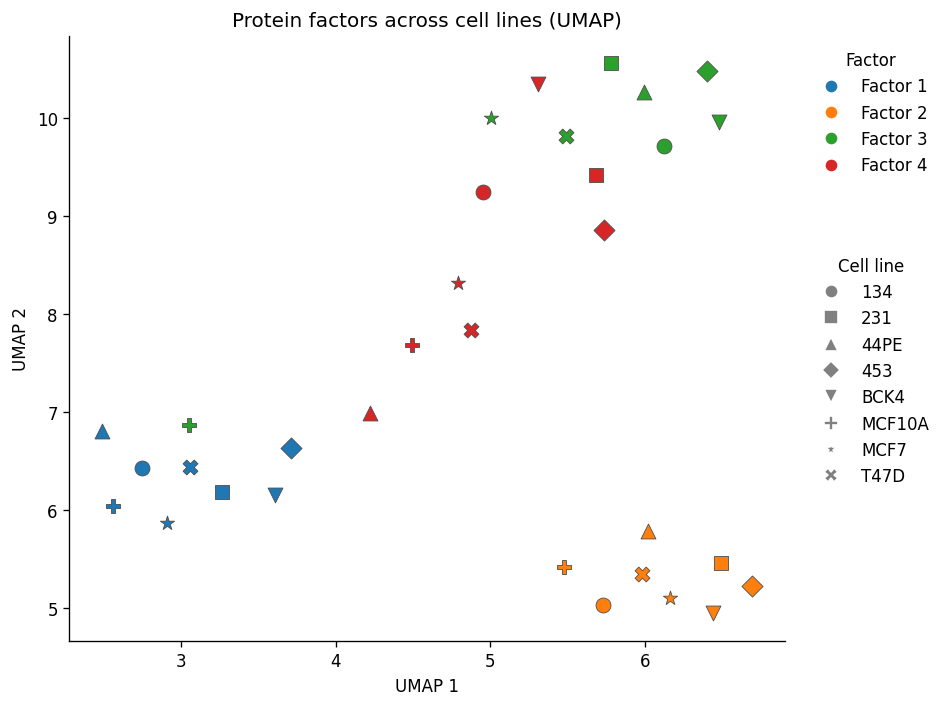

In [6]:
cross_cellline_embedding(
    protein_factor_df, method="umap",
    title="Protein factors across cell lines (UMAP)"
);

### 2.3 Cosine-similarity clustermap:

Each square is the similarity of two factors' protein weights, from 1 (same proteins, same directions) through 0 (unrelated) to -1 (same proteins, opposite directions). Red blocks are factors that recur across cell lines.

1. $S_{ab} \leftarrow \cos(\mathbf{x}_a, \mathbf{x}_b)$ for all pairs of rows of $X_P$.
2. $d_{ab} \leftarrow (1 - S_{ab}) / 2$; average-linkage clustering on $d$.
3. Heatmap of $S$, rows and columns in dendrogram order, annotated with $S_{ab}$.

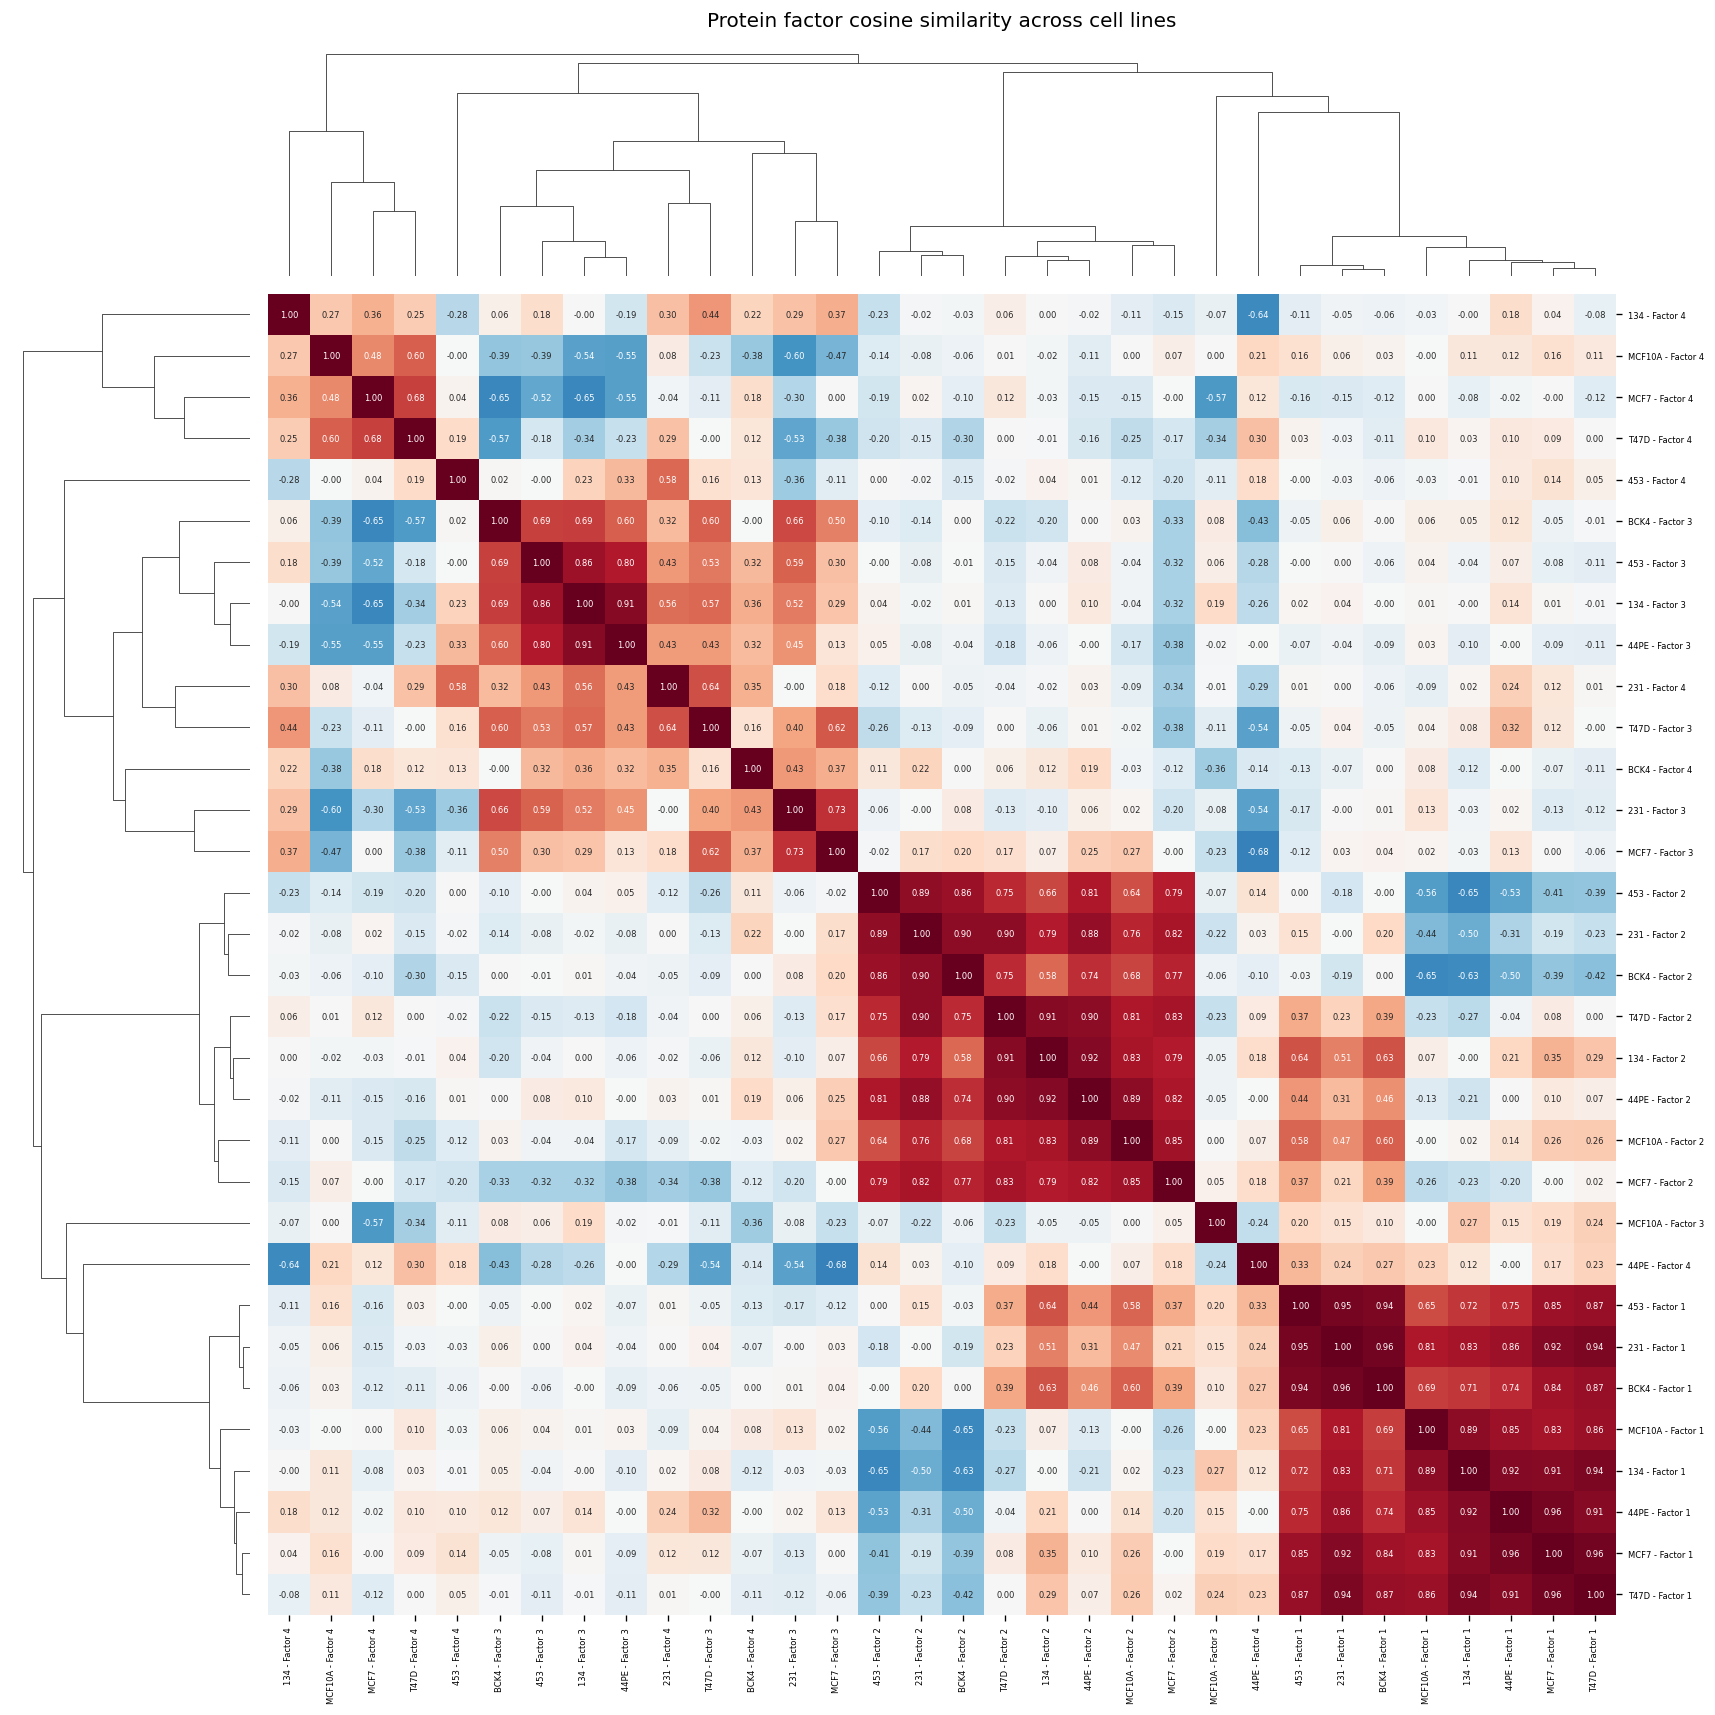

In [7]:
cross_cellline_clustermap(
    protein_factor_df,
    title="Protein factor cosine similarity across cell lines"
);

### 2.4 Loadings per protein:

For each protein, the spread of its weight on each factor across the 8 cell lines. A narrow violin away from zero means the protein plays the same role in that factor in every line.

1. For each protein $r$ and factor $f$: violin of $\{P^{(\ell)}_{rf}\}_{\ell=1}^{L}$ (aligned loadings, 8 values); color $= f$.
2. Points $=$ individual cell lines; dashed lines $=$ quartiles, long dashes $=$ median.

Pooling assumes factor $f$ is the same program in every line; check its block in 2.3.

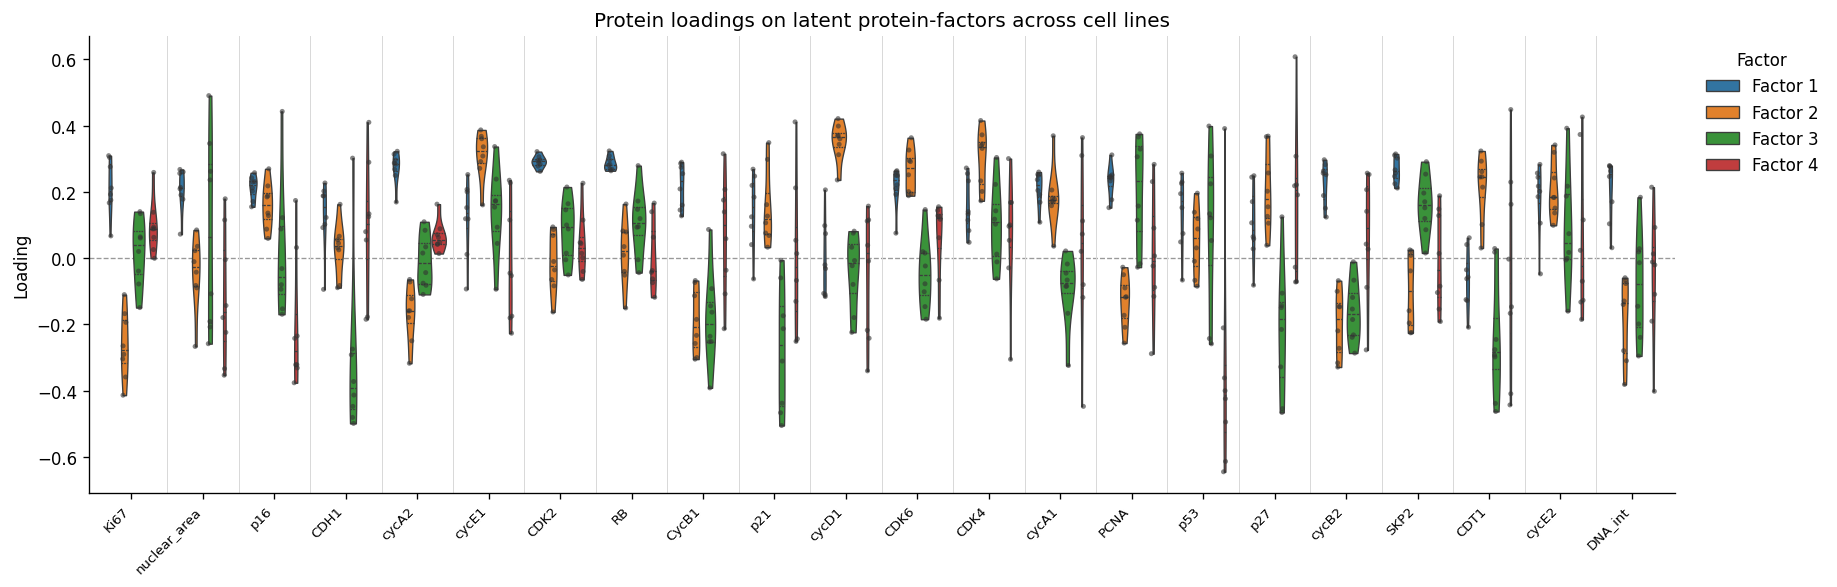

In [8]:
cross_cellline_loading_violins(
    protein_factor_df, factors=["Factor 1", "Factor 2", "Factor 3", "Factor 4"],
    title="Protein loadings on latent protein-factors across cell lines"
);

## 3. Protein factors by treatment:

A factor's protein weights are scaled by how strongly a drug engages the factor in that cell line (averaged over G1, G2 and S). The result is the protein change, relative to the cell line's average over all drugs and phases, that the drug produces through this factor.

1. For each $(\ell, t, f)$: row $\mathbf{y}_{\ell t f} \leftarrow \bar{\mathcal{F}}^{(\ell)}_{tf}\, P^{(\ell)}_{:,f} \in \mathbb{R}^{p}$.
2. $Y \leftarrow$ all rows, $Y \in \mathbb{R}^{L \cdot 8 \cdot p_F \times p}$ ($256 \times 22$).

$\mathbf{y}_{\ell t f}$ does not depend on the sign of $P^{(\ell)}_{:,f}$.

In [9]:
protein_factor_by_treatment_df = cross_cellline_protein_factors_by_treatment(cct_dict)
print(f"Protein factor by treatment matrix: {protein_factor_by_treatment_df.shape}")

protein_factor_by_treatment_df.head(8)

Protein factor by treatment matrix: (256, 22)


Ki67  nuclear_area       p16      CDH1  \
cell_line treatment factor                                                 
134       CVT-313   Factor 1 -0.346580     -0.291634 -0.173555 -0.210618   
                    Factor 2  0.171235      0.128247 -0.419383 -0.069816   
                    Factor 3  0.012938     -0.021690 -0.006352 -0.058778   
                    Factor 4 -0.003005     -0.020810 -0.020219 -0.014526   
          Control   Factor 1 -0.122843     -0.103368 -0.061515 -0.074652   
                    Factor 2  0.004495      0.003367 -0.011010 -0.001833   
                    Factor 3  0.041255     -0.069159 -0.020254 -0.187417   
                    Factor 4 -0.018316     -0.126826 -0.123225 -0.088524   

                                 cycA2     cycE1      CDK2        RB  \
cell_line treatment factor                                             
134       CVT-313   Factor 1 -0.351620 -0.012786 -0.330235 -0.295443   
                    Factor 2  0.111690 -0.560336 -0.134331 -0.254106   
                    Factor 3 -0.015252  0.034691  0.029369  0.029698   
                    Factor 4 -0.004853 -0.013367 -0.000120 -0.019315   
          Control   Factor 1 -0.124629 -0.004532 -0.117049 -0.104718   
                    Factor 2  0.002932 -0.014710 -0.003526 -0.006671   
                    Factor 3 -0.048633  0.110615  0.093644  0.094695   
                    Factor 4 -0.029575 -0.081462 -0.000732 -0.117712   

                                 CycB1       p21  ...      CDK4     cycA1  \
cell_line treatment factor                        ...                       
134       CVT-313   Factor 1 -0.324622 -0.139772  ... -0.053497 -0.188876   
                    Factor 2  0.114176 -0.117608  ... -0.536104 -0.282159   
                    Factor 3 -0.050852 -0.101829  ...  0.020674  0.004384   
                    Factor 4 -0.006814  0.015148  ... -0.034904  0.051977   
          Control   Factor 1 -0.115060 -0.049541  ... -0.018962 -0.066946   
                    Factor 2  0.002997 -0.003087  ... -0.014074 -0.007407   
                    Factor 3 -0.162146 -0.324689  ...  0.065922  0.013978   
                    Factor 4 -0.041528  0.092318  ... -0.212715  0.316769   

                                  PCNA       p53       p27     cycB2  \
cell_line treatment factor                                             
134       CVT-313   Factor 1 -0.273814 -0.170874  0.091360 -0.332805   
                    Factor 2  0.077751 -0.048074 -0.570112  0.105694   
                    Factor 3  0.073689  0.045213 -0.021306 -0.046691   
                    Factor 4  0.013411  0.074917  0.008352 -0.003143   
          Control   Factor 1 -0.097051 -0.060565  0.032382 -0.117961   
                    Factor 2  0.002041 -0.001262 -0.014966  0.002775   
                    Factor 3  0.234964  0.144164 -0.067937 -0.148878   
                    Factor 4  0.081734  0.456569  0.050903 -0.019155   

                                  SKP2      CDT1     cycE2   DNA_int  
cell_line treatment factor                                            
134       CVT-313   Factor 1 -0.338280  0.143568 -0.118463 -0.312960  
                    Factor 2 -0.034208 -0.380694 -0.531243  0.119083  
                    Factor 3  0.034291 -0.060087  0.043768 -0.040020  
                    Factor 4 -0.021865  0.019353 -0.002742  0.022099  
          Control   Factor 1 -0.119901  0.050887 -0.041988 -0.110927  
                    Factor 2 -0.000898 -0.009994 -0.013946  0.003126  
                    Factor 3  0.109339 -0.191593  0.139559 -0.127606  
                    Factor 4 -0.133251  0.117943 -0.016708  0.134677  

[8 rows x 22 columns]

### 3.1 PCA:

Each point is one drug-factor combination in one cell line, labeled by drug; points close together are conditions that shift the proteins in a similar way.

1. $Z \leftarrow \mathrm{PCA}_2(Y)$.
2. Scatter $Z$, one point per $(\ell, t, f)$: color $= f$, marker $= \ell$, text $= t$.

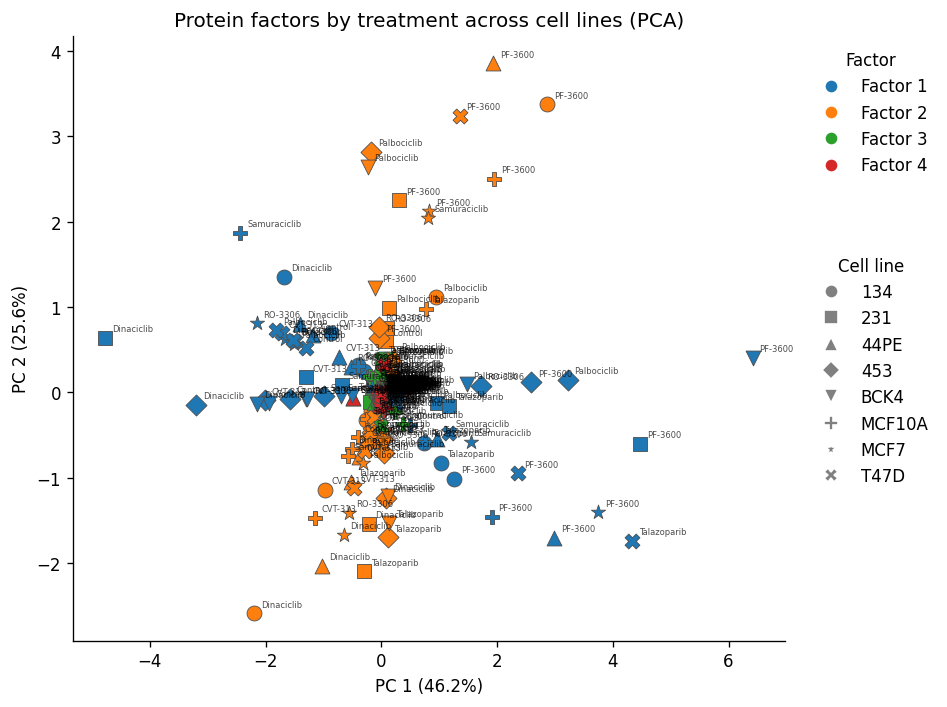

In [10]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="pca",
    title="Protein factors by treatment across cell lines (PCA)"
);

### 3.2 t-SNE:

The same comparison with a nonlinear map that emphasizes local groups; nearby labels share a protein response, distances between groups are not meaningful.

As 3.1 with $Z \leftarrow \mathrm{tSNE}_2(Y)$.

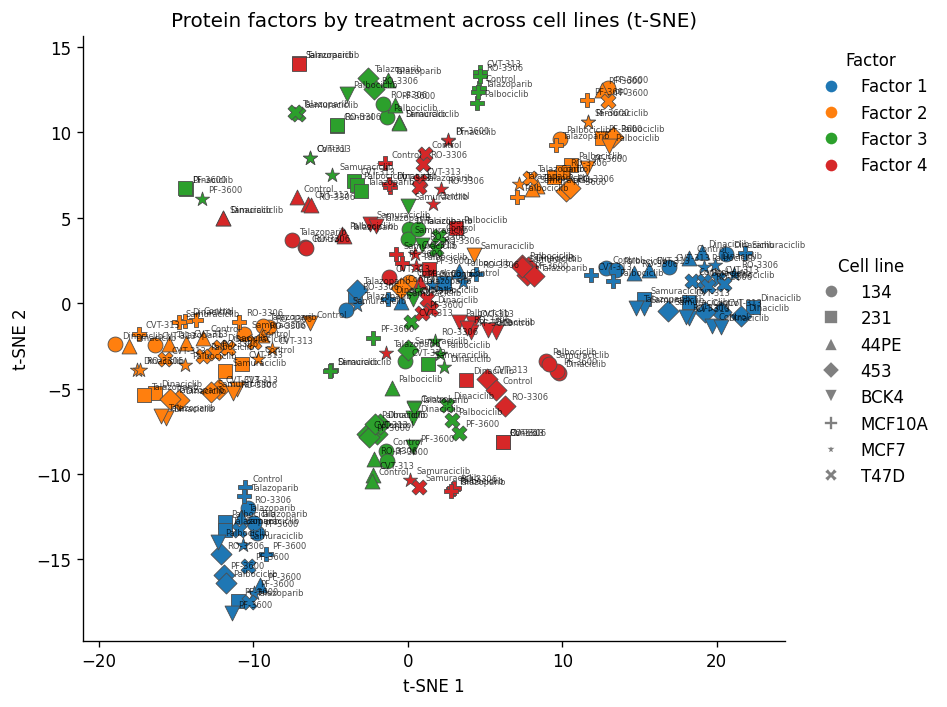

In [11]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="tsne",
    title="Protein factors by treatment across cell lines (t-SNE)"
);

### 3.3 PCA without Factors 1 and 4:

The same comparison as 3.1, restricted to Factors 2 and 3.

As 3.1 on the rows of $Y$ with $f \in \{2, 3\}$.

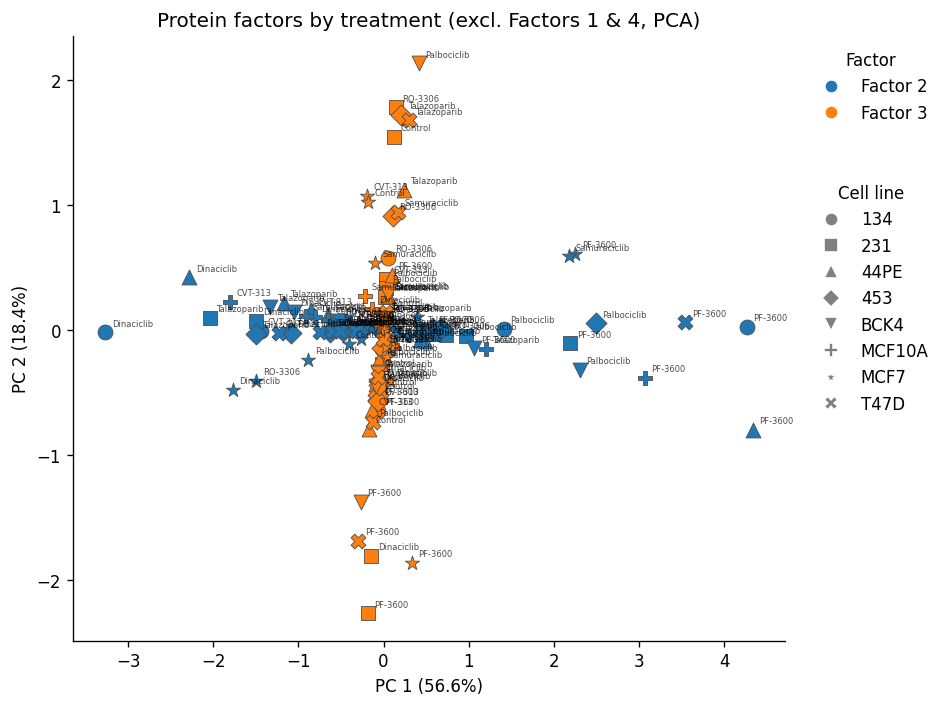

In [12]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="pca",
    exclude_factors=["Factor 1", "Factor 4"],
    title="Protein factors by treatment (excl. Factors 1 & 4, PCA)"
);

### 3.4 t-SNE without Factors 1 and 4:

The same comparison as 3.2, restricted to Factors 2 and 3.

As 3.2 on the rows of $Y$ with $f \in \{2, 3\}$.

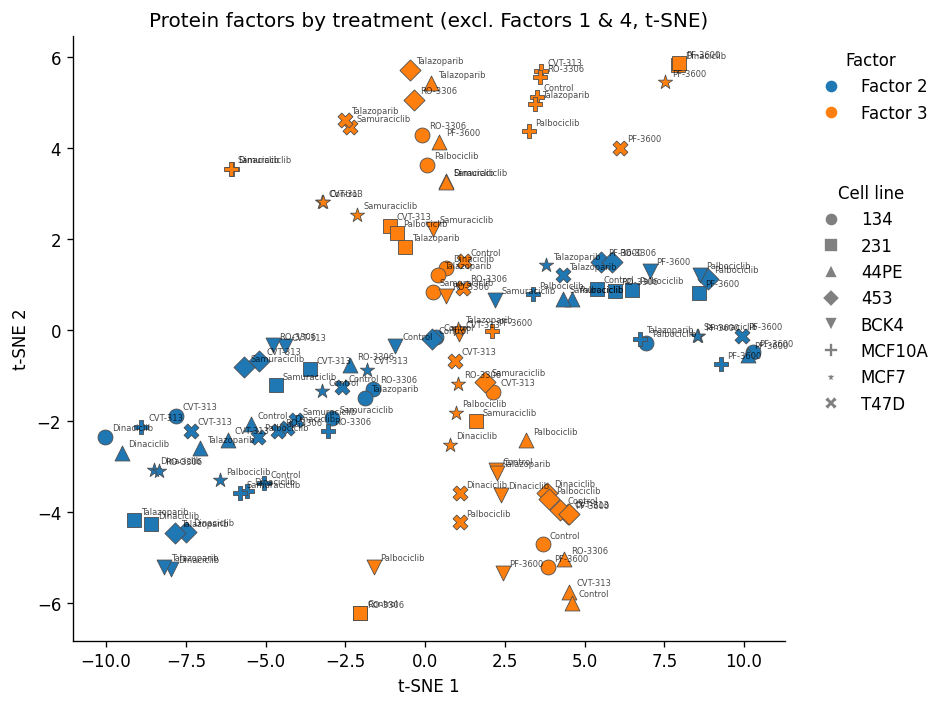

In [13]:
cross_cellline_embedding(
    protein_factor_by_treatment_df, method="tsne",
    exclude_factors=["Factor 1", "Factor 4"],
    title="Protein factors by treatment (excl. Factors 1 & 4, t-SNE)"
);

## 4. Phase profiles:

For each drug in each cell line: how active a factor is in G1, G2 and S. Two conditions with the same profile engage the factor with the same timing through the cell cycle, possibly at different strengths.

1. For each $(\ell, t, f)$: row $\boldsymbol{\phi}_{\ell t f} \leftarrow \mathcal{F}^{(\ell)}_{t,:,f} \in \mathbb{R}^{c}$ (activity of $f$ in G1, G2, S).
2. $\Phi \leftarrow$ all rows ($256 \times 3$).

$\boldsymbol{\phi}_{\ell t f}$ flips with the sign of $P^{(\ell)}_{:,f}$, hence the alignment in 1.1.

In [14]:
phase_profiles_df = cross_cellline_phase_profiles(cct_dict)
print(f"Phase profiles matrix: {phase_profiles_df.shape}")
phase_profiles_df.head(8)

Phase profiles matrix: (256, 3)


G1        G2         S
cell_line treatment factor                                
134       CVT-313   Factor 1 -4.215979  1.621286 -0.769574
                    Factor 2 -0.939302 -1.928999 -1.799757
                    Factor 3 -0.862988 -0.447844  1.915893
                    Factor 4 -0.247459  0.068176 -0.169505
          Control   Factor 1 -3.955857  3.033144 -0.269728
                    Factor 2  0.264527 -0.109450 -0.277621
                    Factor 3 -0.265254  0.087727  2.106810
                    Factor 4 -0.537936 -0.743042 -0.844663

### 4.1 Factor 1 clustermap:

Similarity of the Factor 1 phase profiles of all drug-by-cell-line conditions, ignoring overall strength: 1 = same timing, -1 = opposite timing. The side bars show whether a block is formed by one drug or by one cell line.

1. Rows: $\boldsymbol{\phi}_{\ell t 1}$ for all $(\ell, t)$ ($64 \times 3$).
2. $S_{ab} \leftarrow \cos(\boldsymbol{\phi}_a, \boldsymbol{\phi}_b)$; $d_{ab} \leftarrow (1 - S_{ab}) / 2$; average linkage.
3. Heatmap of $S$ in dendrogram order; side bars: cell line, treatment.

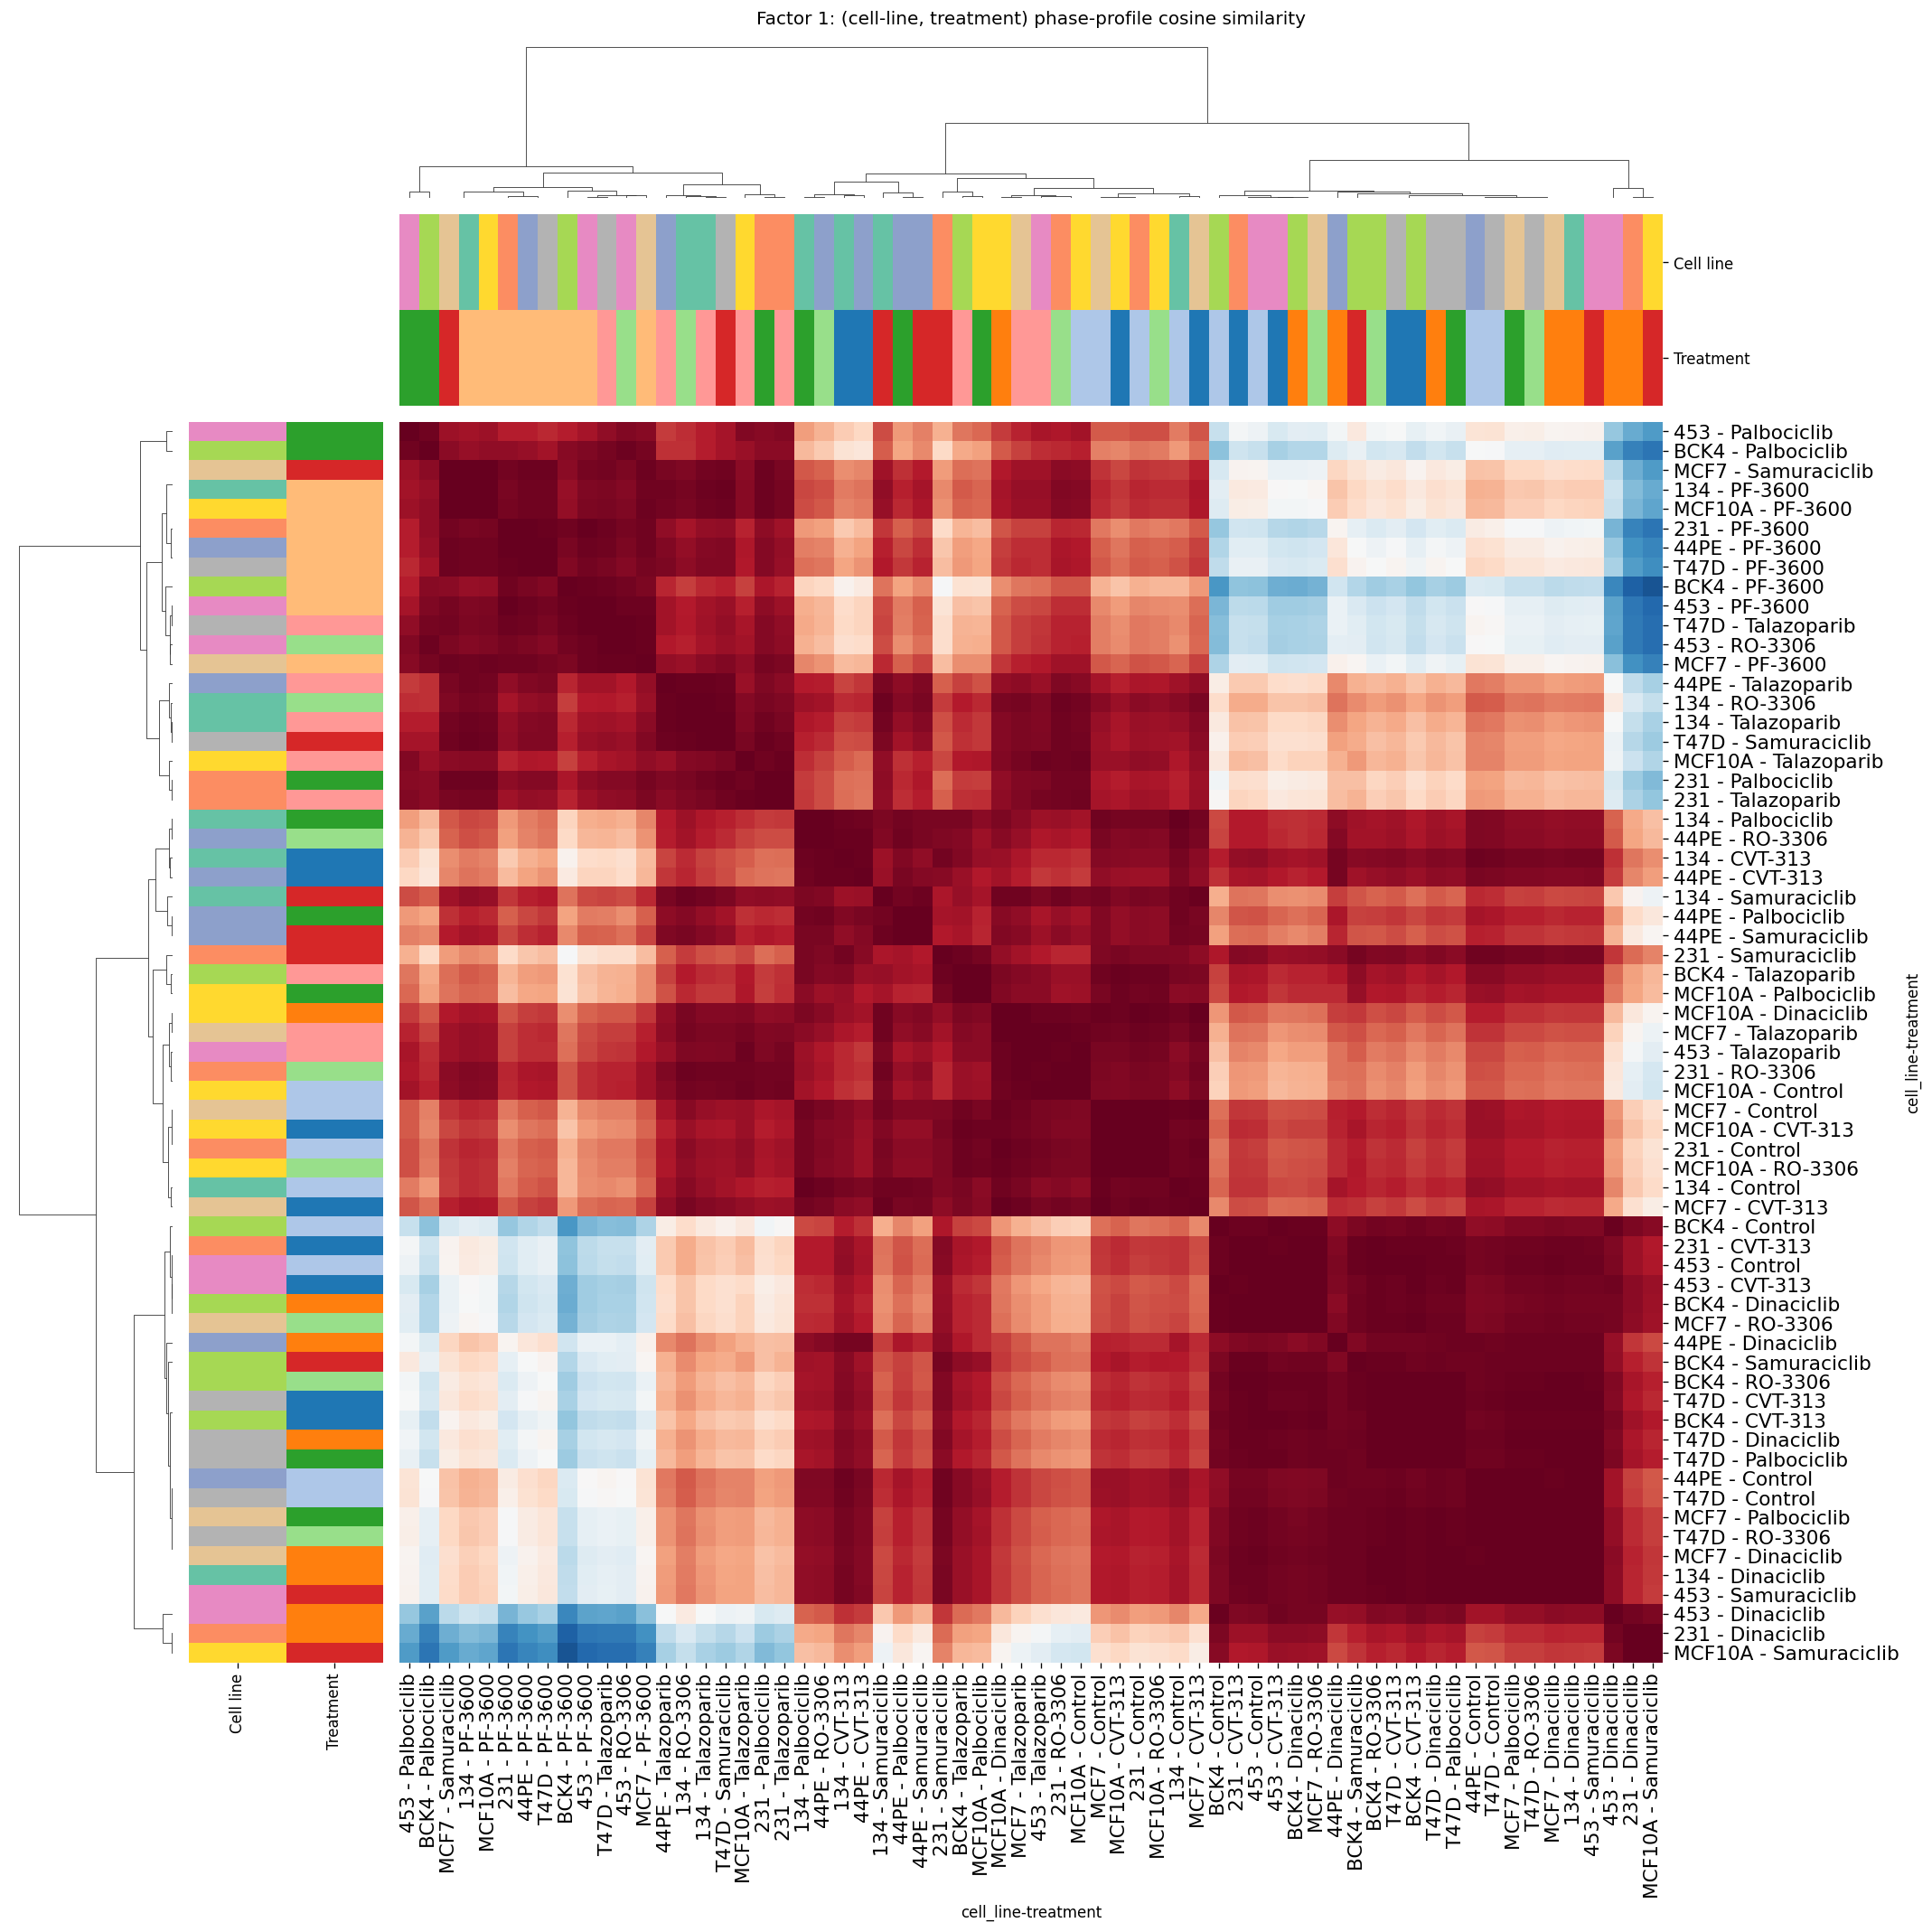

In [15]:
cross_cellline_clustermap(
    phase_profiles_df.xs("Factor 1", level="factor"),
    annotate=False,
    title="Factor 1: (cell-line, treatment) phase-profile cosine similarity",
);

### 4.2 Factor 2 clustermap:

The same comparison as 4.1 for Factor 2.

As 4.1 with $f = 2$.

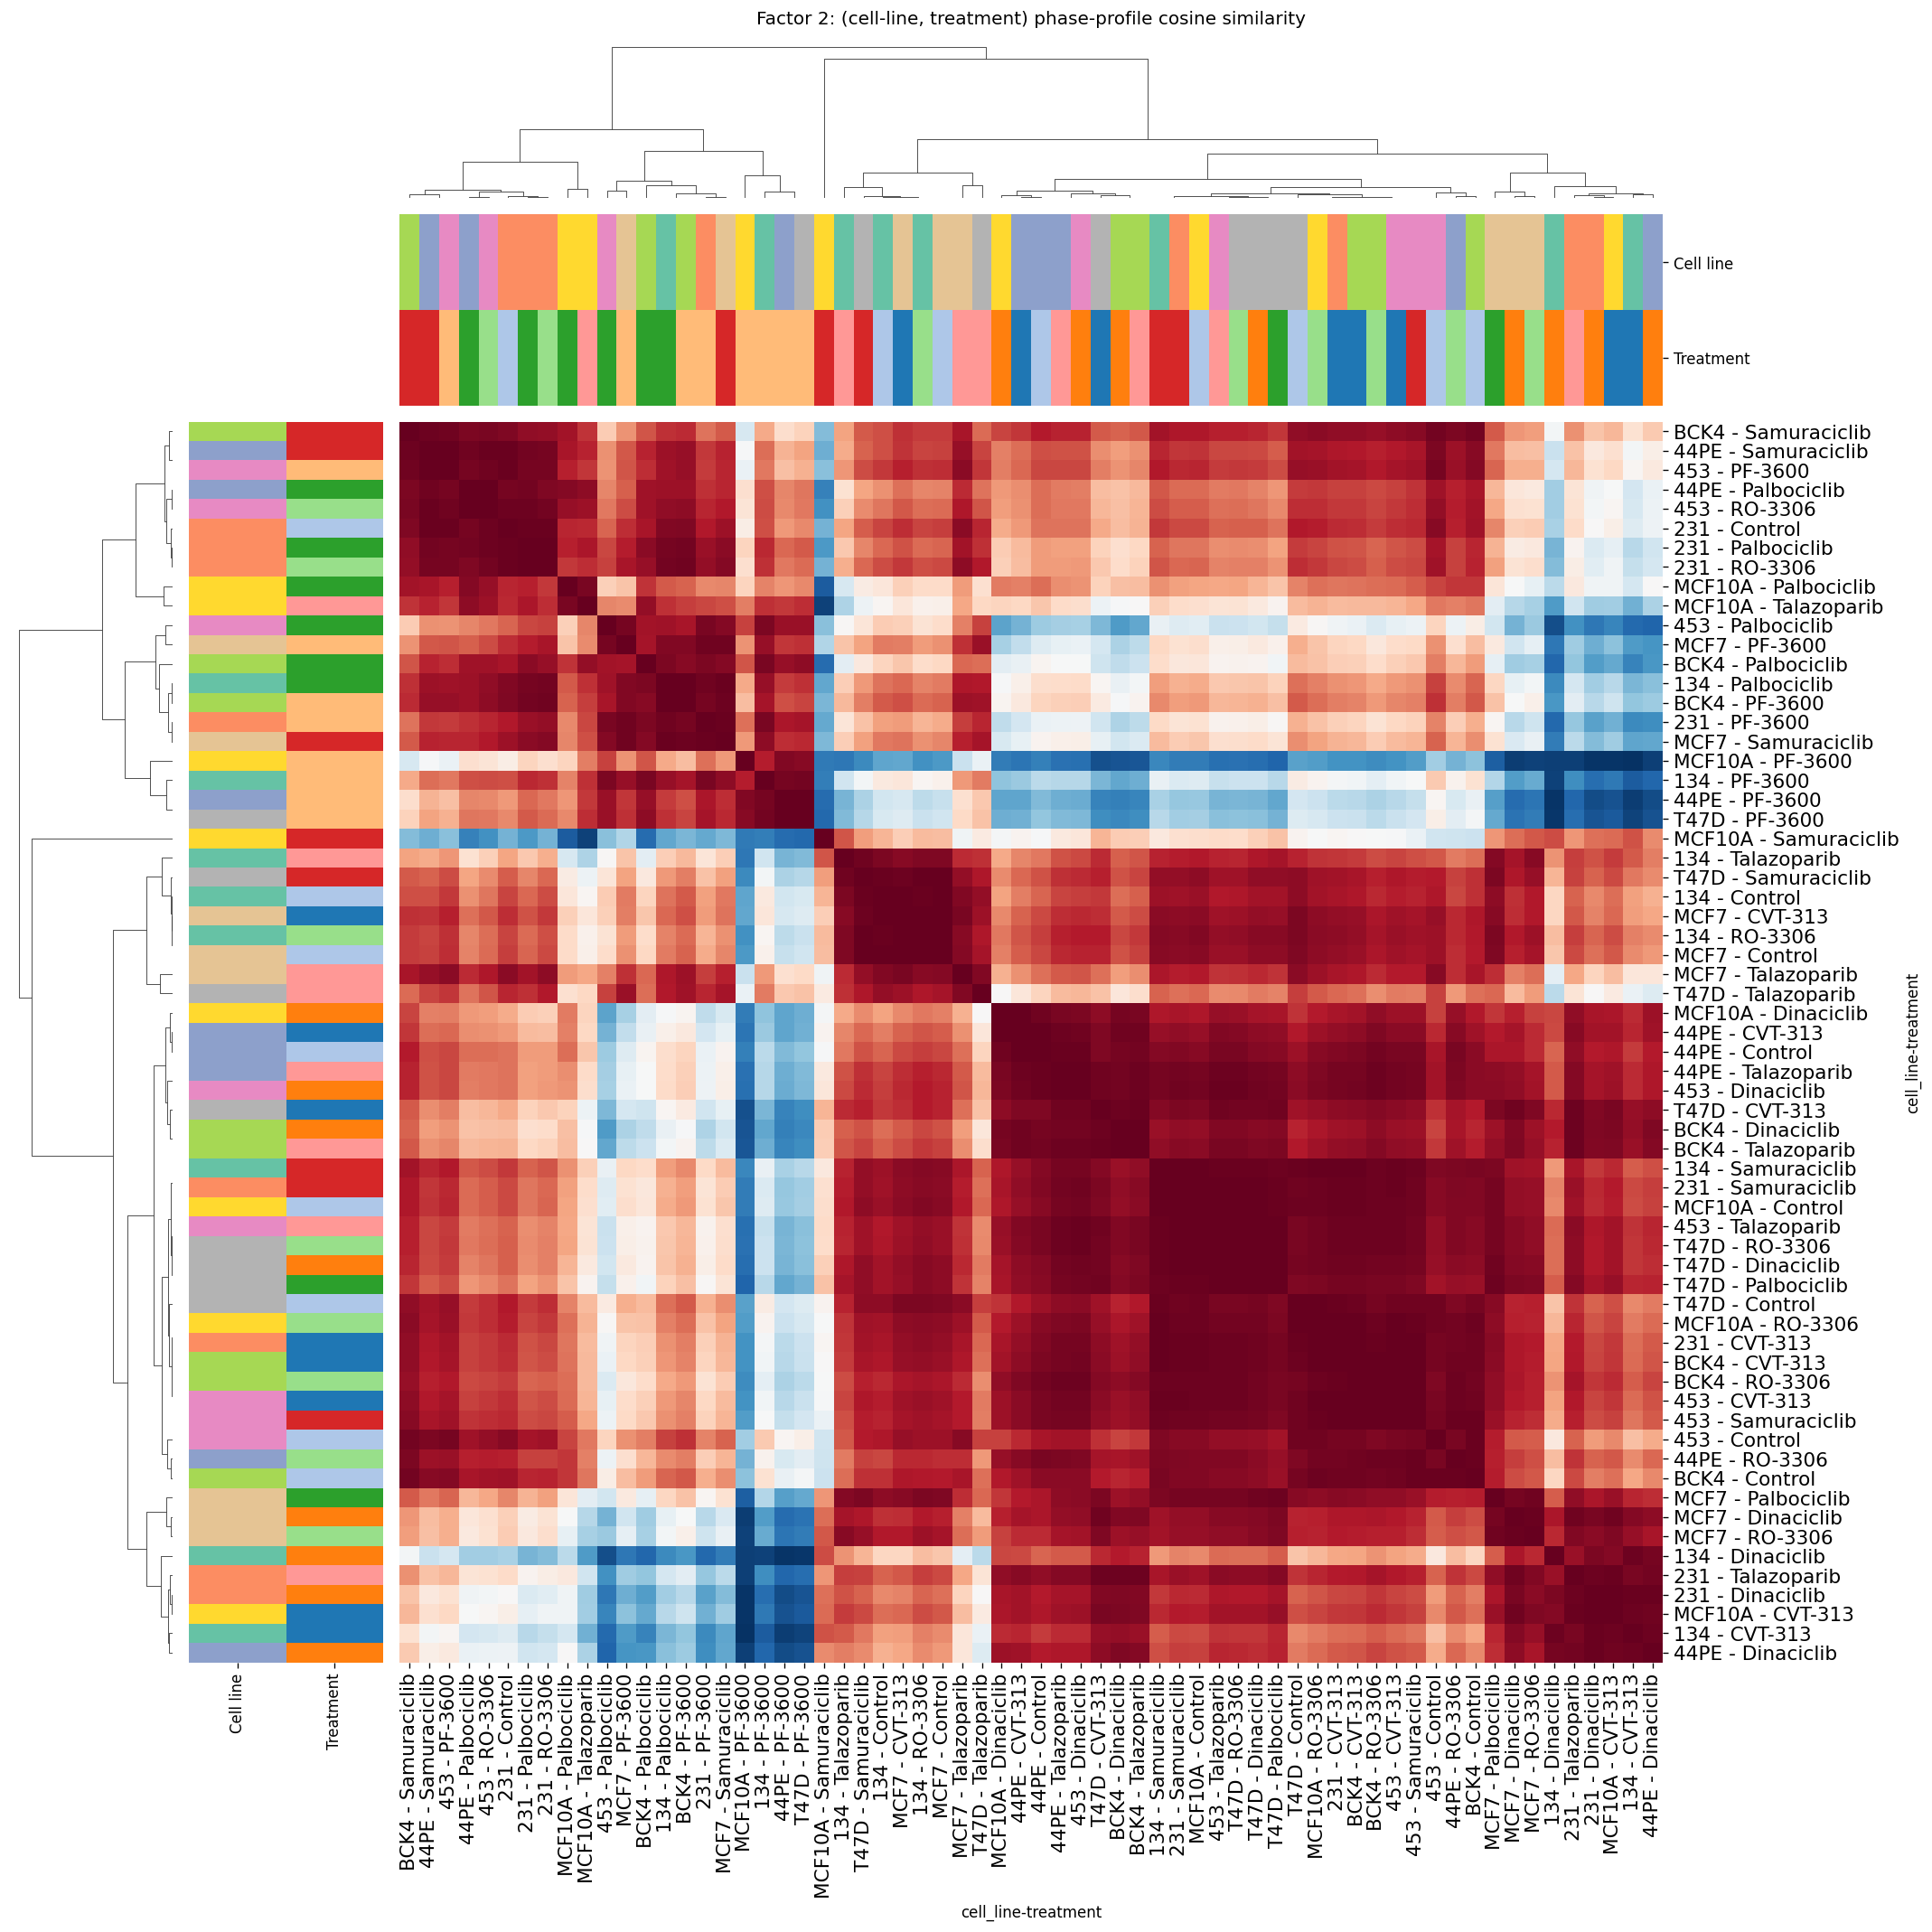

In [16]:
cross_cellline_clustermap(
    phase_profiles_df.xs("Factor 2", level="factor"),
    annotate=False,
    title="Factor 2: (cell-line, treatment) phase-profile cosine similarity",
);

### 4.3 Factor activity by treatment:

How strongly each drug engages each factor in G1, G2 and S, with one point per cell line; 0 is the cell line's average over all drugs and phases. A drug that shifts a factor the same way in every line gives a narrow violin offset from Control's in the same phase.

1. For each $(t, j, f)$: violin of $\{\mathcal{F}^{(\ell)}_{tjf}\}_{\ell=1}^{L}$ (entries of $\Phi$, aligned, 8 values); x $= t$, color $= j$, one panel per $f$.
2. Points $=$ individual cell lines; dashed lines $=$ quartiles, long dashes $=$ median.

$T^{(\ell)}$ and $C^{(\ell)}$ are square and orthogonal, so $\mathcal{F}^{(\ell)}_{tjf} = \sum_r \mathcal{X}^{(\ell)}_{tjr} P^{(\ell)}_{rf}$: the z-scored mean protein profile of drug $t$ in phase $j$ projected onto the protein weights of factor $f$. It sums to 0 over all $(t, j)$ within each line.

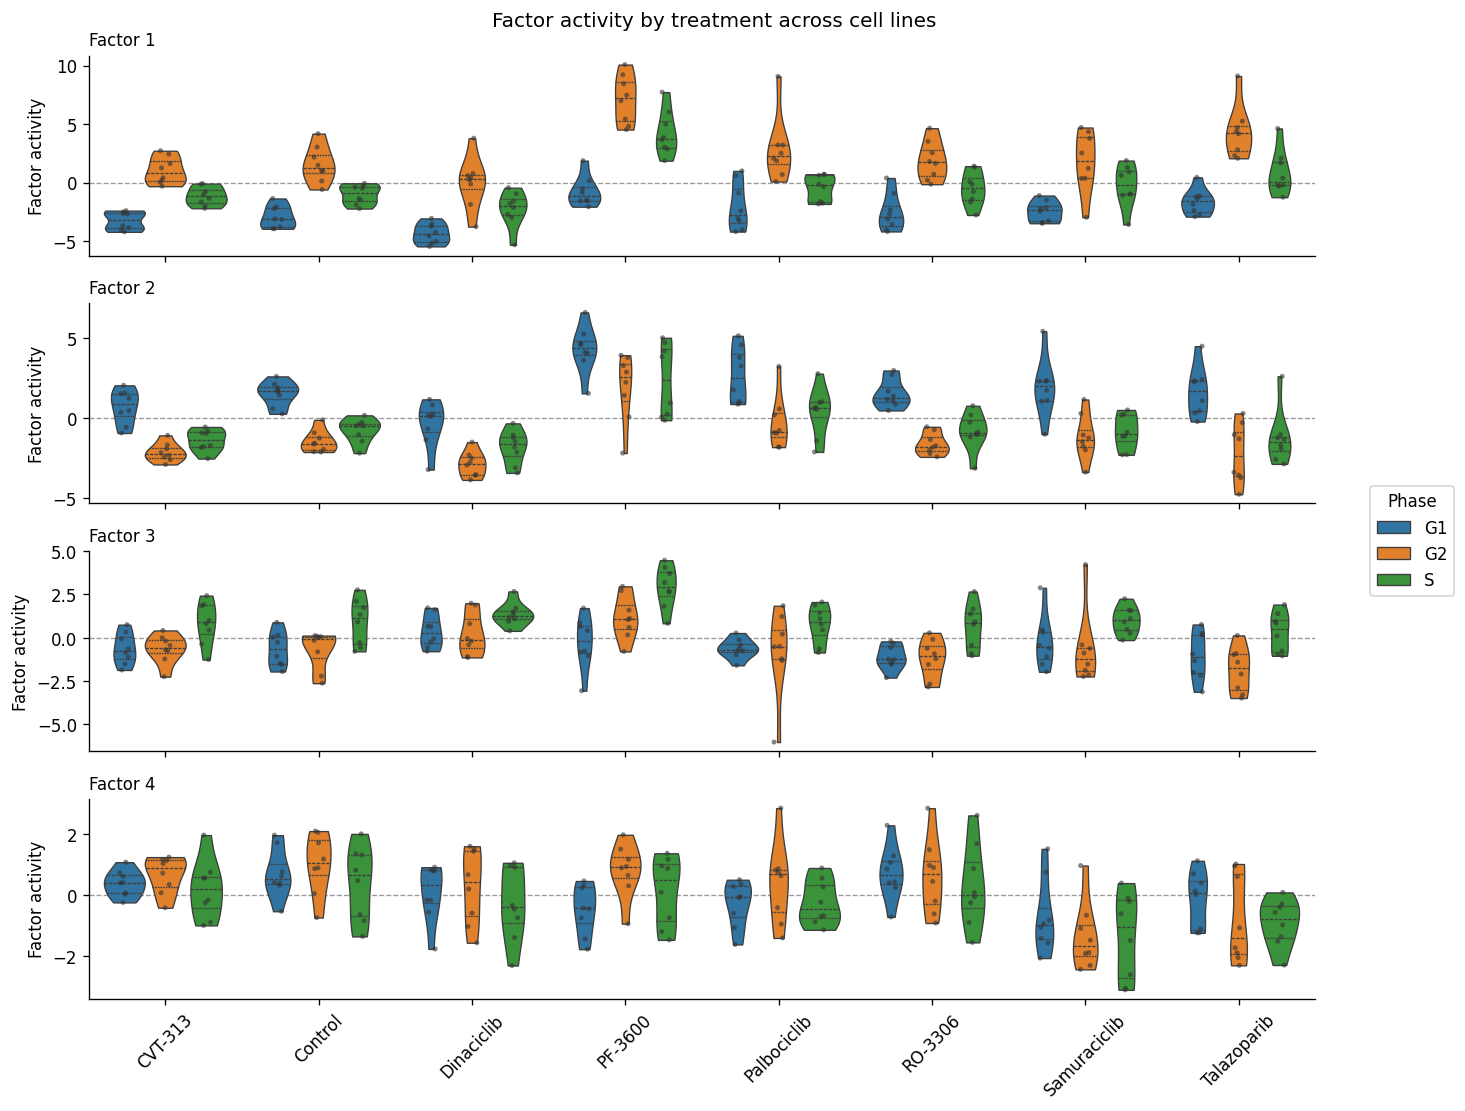

In [17]:
cross_cellline_treatment_violins(
    phase_profiles_df,
    title="Factor activity by treatment across cell lines"
);

## 5. CARVE clustering of phase profiles:

The protein change a factor produces under one drug, in one cell line and one phase: its protein weights scaled by its activity there. Averaging over the three phases gives the quantities of section 3.

Protein influence, used by the heatmaps and violins below:

1. For each $(\ell, t, j, f)$: row $\mathbf{q}_{\ell t j f} \leftarrow \mathcal{F}^{(\ell)}_{tjf}\, P^{(\ell)}_{:,f} \in \mathbb{R}^{p}$.
2. Averaging over $j$ gives $\mathbf{y}_{\ell t f}$ (section 3).

In [17]:
protein_influence_df = cross_cellline_protein_influence(cct_dict)
print(f"Protein influence matrix: {protein_influence_df.shape}")

protein_influence_df.head(8)

Protein influence matrix: (768, 22)


Ki67  nuclear_area       p16  \
cell_line treatment phase factor                                       
134       CVT-313   G1    Factor 1 -1.302965     -1.096397 -0.652479   
                          Factor 2  0.103367      0.077417 -0.253163   
                          Factor 3 -0.055361      0.092807  0.027180   
                          Factor 4 -0.006397     -0.044294 -0.043036   
                    G2    Factor 1  0.501065      0.421628  0.250916   
                          Factor 2  0.212280      0.158988 -0.519910   
                          Factor 3 -0.028730      0.048162  0.014105   
                          Factor 4  0.001762      0.012203  0.011857   

                                        CDH1     cycA2     cycE1      CDK2  \
cell_line treatment phase factor                                             
134       CVT-313   G1    Factor 1 -0.791817 -1.321912 -0.048068 -1.241514   
                          Factor 2 -0.042145  0.067422 -0.338251 -0.081090   
                          Factor 3  0.251500  0.065262 -0.148438 -0.125663   
                          Factor 4 -0.030917 -0.010329 -0.028450 -0.000255   
                    G2    Factor 1  0.304499  0.508351  0.018485  0.477434   
                          Factor 2 -0.086551  0.138462 -0.694649 -0.166531   
                          Factor 3  0.130515  0.033867 -0.077031 -0.065213   
                          Factor 4  0.008518  0.002846  0.007838  0.000070   

                                          RB     CycB1       p21  ...  \
cell_line treatment phase factor                                  ...   
134       CVT-313   G1    Factor 1 -1.110716 -1.220413 -0.525471  ...   
                          Factor 2 -0.153393  0.068923 -0.070995  ...   
                          Factor 3 -0.127074  0.217588  0.435710  ...   
                          Factor 4 -0.041111 -0.014504  0.032242  ...   
                    G2    Factor 1  0.427134  0.469319  0.202074  ...   
                          Factor 2 -0.315016  0.141544 -0.145798  ...   
                          Factor 3 -0.065945  0.112916  0.226110  ...   
                          Factor 4  0.011326  0.003996 -0.008883  ...   

                                        CDK4     cycA1      PCNA       p53  \
cell_line treatment phase factor                                             
134       CVT-313   G1    Factor 1 -0.201121 -0.710079 -1.029401 -0.642399   
                          Factor 2 -0.323623 -0.170327  0.046935 -0.029020   
                          Factor 3 -0.088462 -0.018757 -0.315305 -0.193459   
                          Factor 4 -0.074290  0.110631  0.028546  0.159456   
                    G2    Factor 1  0.077343  0.273066  0.395864  0.247039   
                          Factor 2 -0.664609 -0.349793  0.096389 -0.059597   
                          Factor 3 -0.045907 -0.009734 -0.163626 -0.100395   
                          Factor 4  0.020467 -0.030479 -0.007864 -0.043931   

                                         p27     cycB2      SKP2      CDT1  \
cell_line treatment phase factor                                             
134       CVT-313   G1    Factor 1  0.343468 -1.251180 -1.271762  0.539742   
                          Factor 2 -0.344152  0.063803 -0.020650 -0.229809   
                          Factor 3  0.091166  0.199784 -0.146725  0.257105   
                          Factor 4  0.017778 -0.006690 -0.046538  0.041192   
                    G2    Factor 1 -0.132083  0.481151  0.489066 -0.207562   
                          Factor 2 -0.706768  0.131029 -0.042408 -0.471947   
                          Factor 3  0.047310  0.103677 -0.076142  0.133424   
                          Factor 4 -0.004898  0.001843  0.012821 -0.011348   

                                       cycE2   DNA_int  
cell_line treatment phase factor                        
134       CVT-313   G1    Factor 1 -0.445360 -1.176572  
                          Factor 2 -0.320688  0.071885  
                 

We group the drug-by-cell-line conditions by the timing of a factor's activity across G1, G2 and S, ignoring overall strength. CARVE tries several clustering methods and numbers of groups on resampled data and keeps the largest number of groups that carries over to held-out data nearly as well as the best choice.

Clustering of factor $f$ (`run_carve`):

1. $\mathbf{x}_{\ell t} \leftarrow \boldsymbol{\phi}_{\ell t f} / \|\boldsymbol{\phi}_{\ell t f}\|$, so that $\|\mathbf{x}_a - \mathbf{x}_b\|^2 = 2\,(1 - \cos(\boldsymbol{\phi}_a, \boldsymbol{\phi}_b))$.
2. CARVE on the 64 points $\mathbf{x}_{\ell t}$: KMeans, Ward, self-tuning spectral (no feature scaling); $k = 2, \dots, 8$; 100 resamples.
3. $\hat{k} \leftarrow$ largest $k$ within one standard error of the best generalizability (ARI).
4. Labels $\leftarrow$ average-linkage cut of the consensus matrix at $\hat{k}$.

In [18]:
ks = list(range(2, 9))
carve_grids = [
    (KMeans, {"n_clusters": ks}),
    (AgglomerativeClustering, {"n_clusters": ks, "linkage": ["ward"]}),
    (SpectralClustering, {"n_clusters": ks, "affinity": ["self_tuning"], "scale": [False]}),
]


def run_carve(factor, measure="generalizability", rule="1se"):
    """CARVE on the unit-normalized phase profiles of one factor; returns (carve, k, labels)."""
    X = phase_profiles_df.xs(factor, level="factor")
    X = X.div(np.linalg.norm(X.values, axis=1), axis=0)

    carve = CARVE(estimator_param_grids=carve_grids, n_resamples=100, random_state=0, n_jobs=4).fit(X)
    k = carve.get_k(measure=measure, rule=rule)
    labels = pd.Series(carve.get_labels(measure=measure, rule=rule), index=X.index, name="cluster")
    print(f"{factor}: selected k = {k}")
    return carve, k, labels


def plot_carve_diagnostics(carve, factor, measure="generalizability", rule="1se"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    carve.plot_metric_over_n_clusters(measure="stability", rule=rule, ax=axes[0])
    carve.plot_metric_over_n_clusters(measure="generalizability", rule=rule, ax=axes[1])
    fig.suptitle(factor)
    fig.tight_layout()
    carve.plot_consensus_matrix(measure=measure, rule=rule, title=f"{factor}: consensus matrix")

### 5.1 Factor 1:

In [19]:
carve_f1, k_f1, labels_f1 = run_carve("Factor 1")

Factor 1: selected k = 3


How reproducible the grouping is for each number of groups (left: across resamples; right: on held-out data), and how often each pair of conditions landed in the same group (below). Sharp blocks in the lower plot mean well-separated groups.

Diagnostics:

1. Left: stability vs. $k$, one line per estimator configuration, error bars $\pm 1$ SE; dashed line $=$ $k$ the 1-SE rule picks on this metric.
2. Right: the same for generalizability; its dashed line is $\hat{k}$.
3. Below: consensus matrix $M$ of the selected configuration, $M_{ab} =$ fraction of resamples containing $a$ and $b$ in which they share a cluster; top band $=$ labels.

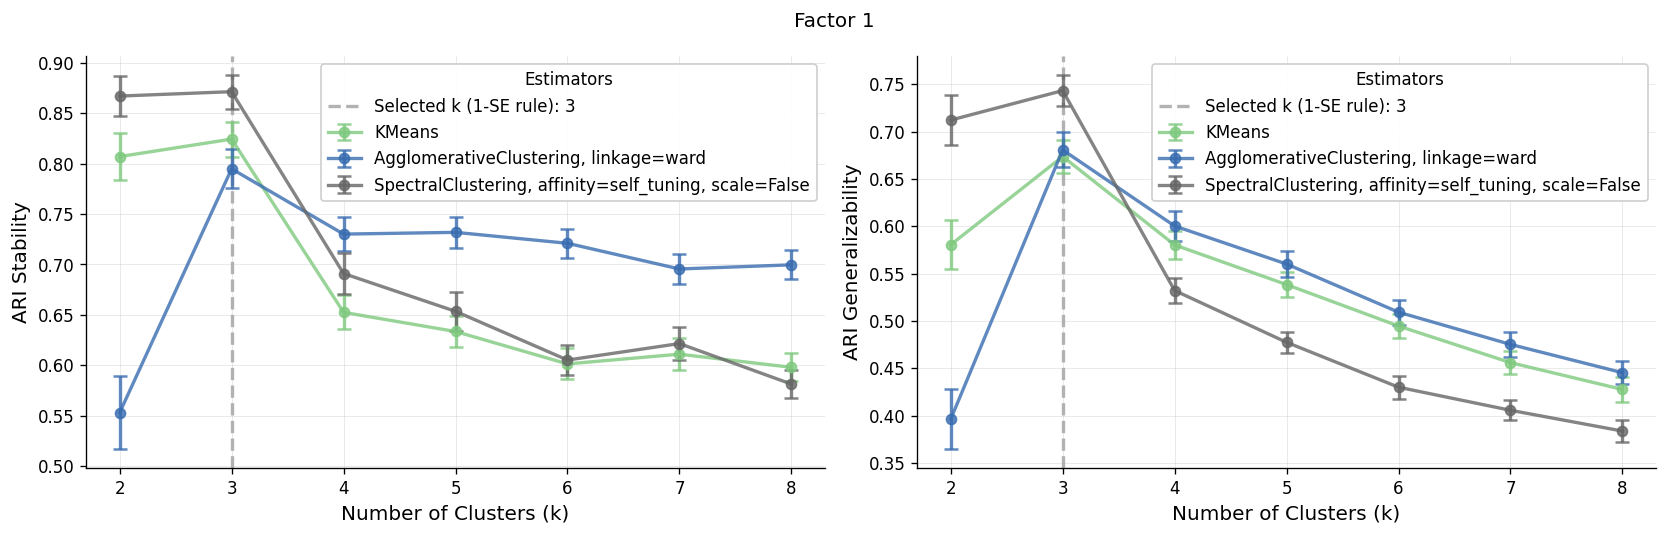

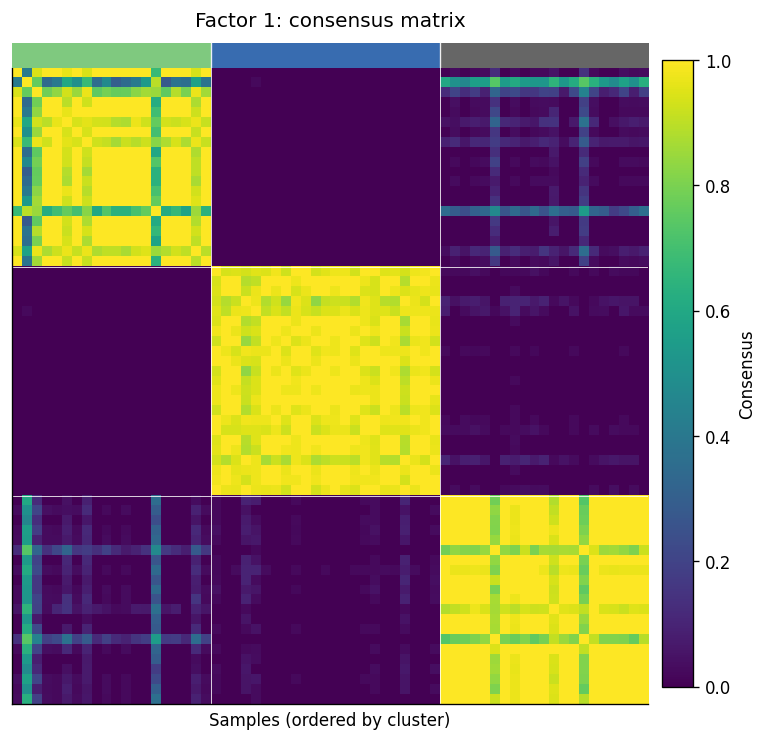

In [20]:
plot_carve_diagnostics(carve_f1, "Factor 1")

The group of each drug in each cell line. A column with a single group means the drug acts with the same timing in all lines; a row with a single group means the line responds with the same timing to all drugs.

Cluster membership: entry $(\ell, t) =$ cluster of $\boldsymbol{\phi}_{\ell t 1}$.

In [21]:
labels_f1.add(1).unstack("treatment")

treatment,CVT-313,Control,Dinaciclib,PF-3600,Palbociclib,RO-3306,Samuraciclib,Talazoparib
cell_line,,,,,,,,
134,3,3,2,1,3,1,3,1
231,2,3,2,1,1,3,3,1
44PE,3,2,2,1,3,3,3,1
453,2,2,2,1,1,1,2,3
BCK4,2,2,2,1,1,2,2,3
MCF10A,3,3,3,1,3,3,2,1
MCF7,3,3,2,1,2,2,1,3
T47D,2,2,2,1,2,2,1,1


The protein change each condition produces through Factor 1 (red = up, blue = down, relative to the cell line's average), grouped by the timing clusters. Within a group, conditions with similar protein changes are placed next to each other.

Phase-averaged protein influence by cluster:

1. Rows: $\mathbf{y}_{\ell t 1}$ for all $(\ell, t)$; columns: proteins.
2. Group rows by cluster $1, \dots, \hat{k}$ (white lines).
3. Within a cluster: rows in the leaf order of average-linkage clustering (Euclidean) of the $\mathbf{y}_{\ell t 1}$.
4. Side bars: cell line, treatment, cluster.

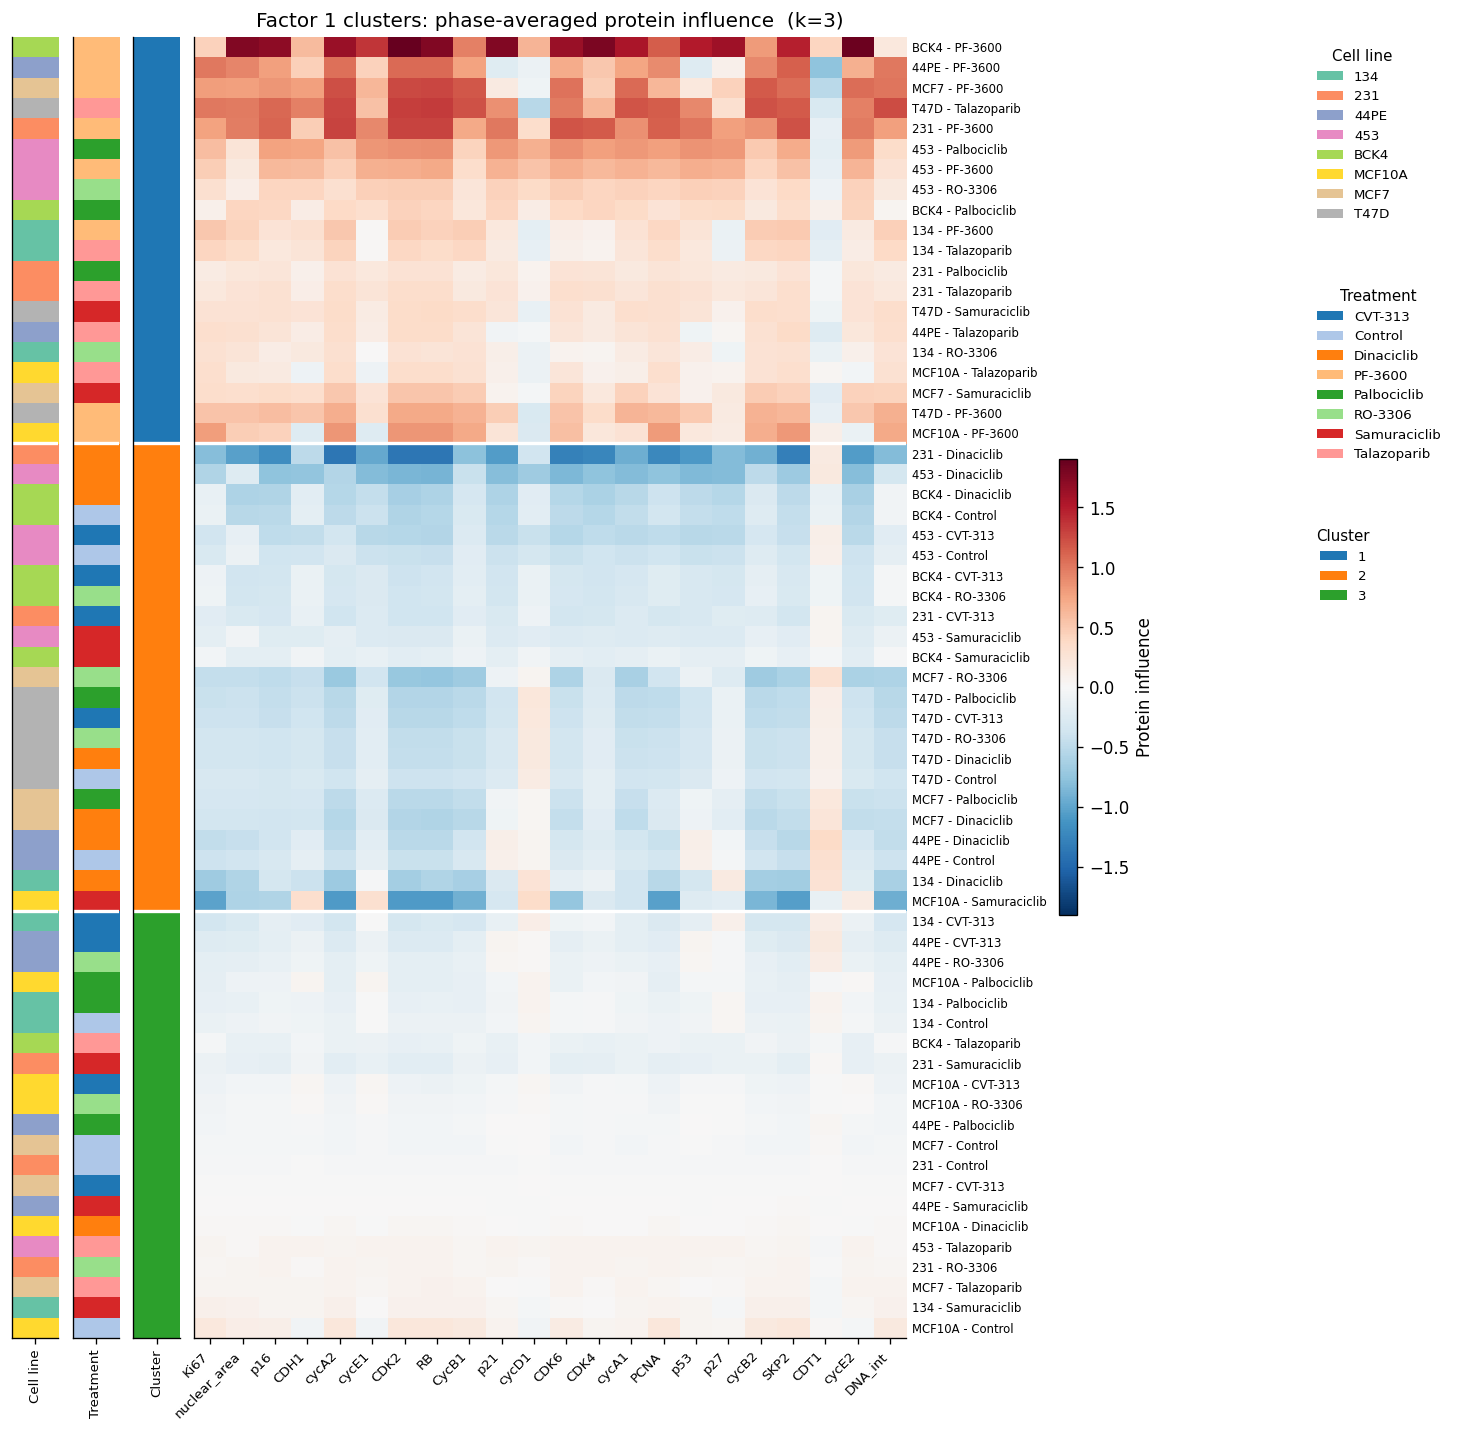

In [22]:
cross_cellline_cluster_heatmap(
    protein_factor_by_treatment_df.xs("Factor 1", level="factor"), labels_f1,
    title="Factor 1 clusters: phase-averaged protein influence",
);

For each protein, the distribution of its factor-driven changes within each timing cluster, pooled over conditions and phases and shown separately per factor. It shows which factors move which proteins in each cluster.

Protein influence by cluster, all factors:

1. For each protein $r$ (panel), cluster $m$ (x-axis) and factor $f'$ (color): violin of $\{q_{\ell t j f', r} : (\ell, t) \in m,\ j \in \{\mathrm{G1}, \mathrm{G2}, \mathrm{S}\}\}$.
2. Points $=$ individual values; dashed lines $=$ quartiles, long dashes $=$ median; grey number $= |m|$.
3. y-axis clipped to the 2nd-98th percentile of the panel.

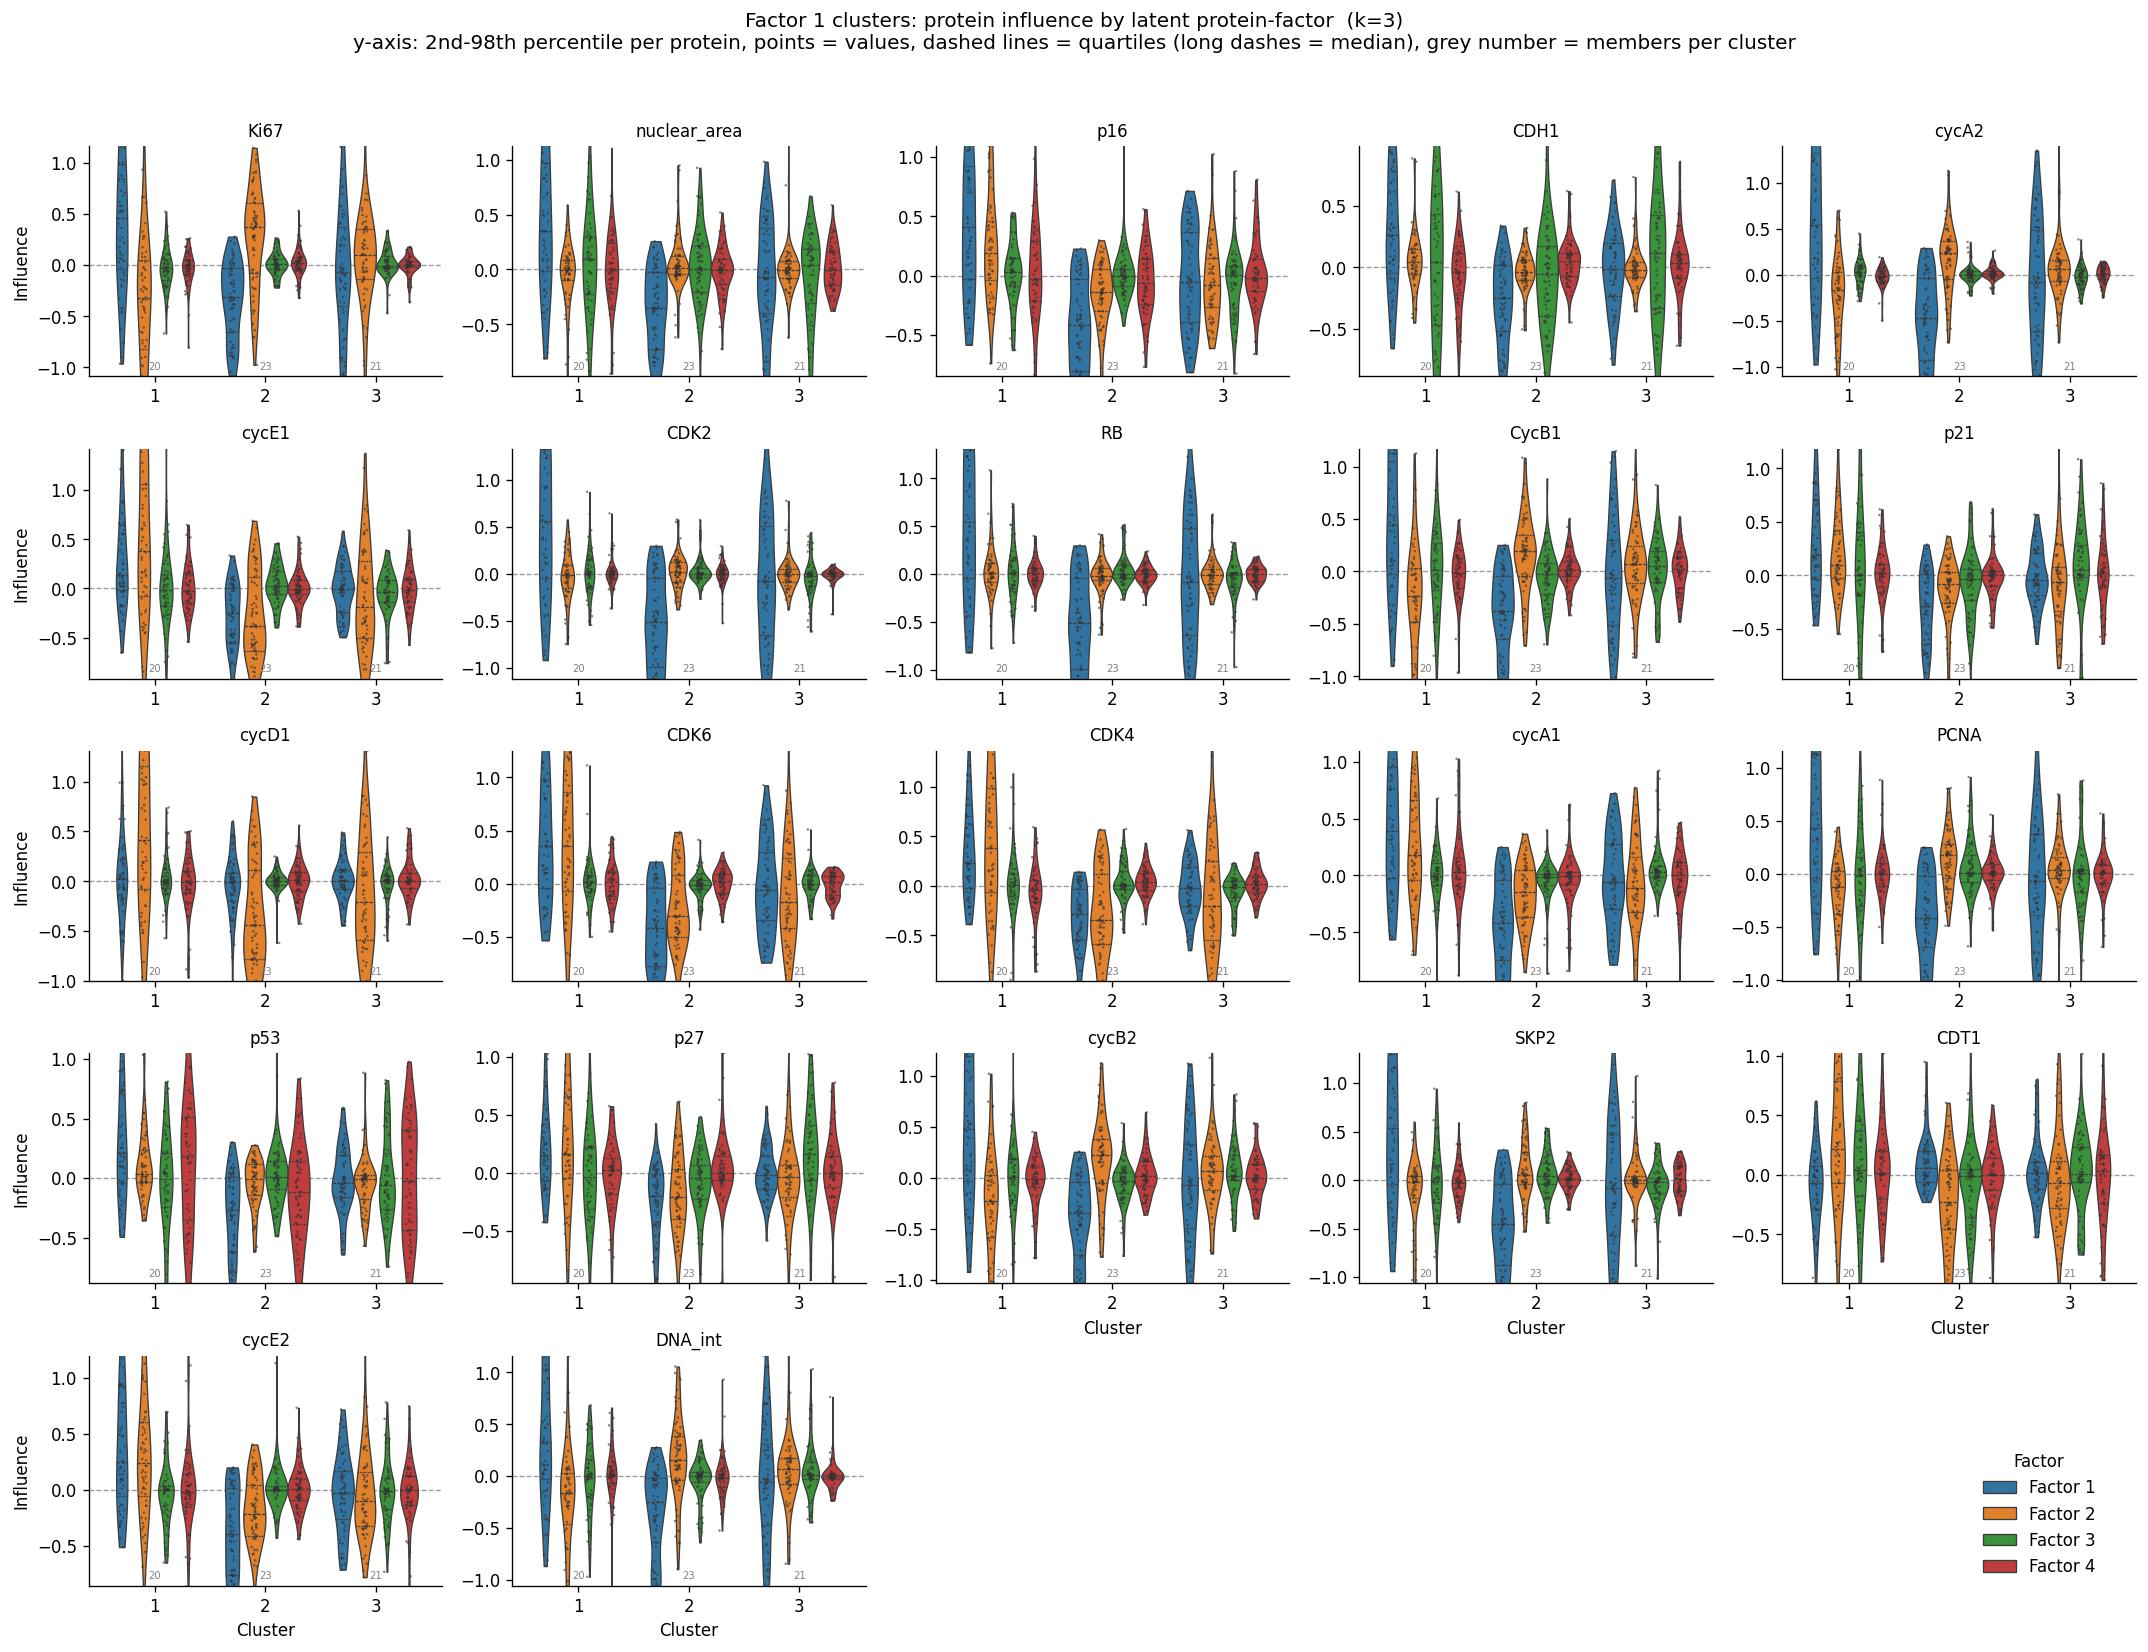

In [24]:
cross_cellline_cluster_violins(
    protein_influence_df, labels_f1,
    title="Factor 1 clusters: protein influence by latent protein-factor",
);

### 5.2 Factor 2:

As 5.1 with $f = 2$.

In [24]:
carve_f2, k_f2, labels_f2 = run_carve("Factor 2")

Factor 2: selected k = 2


Diagnostics for $f = 2$ (as in 5.1).

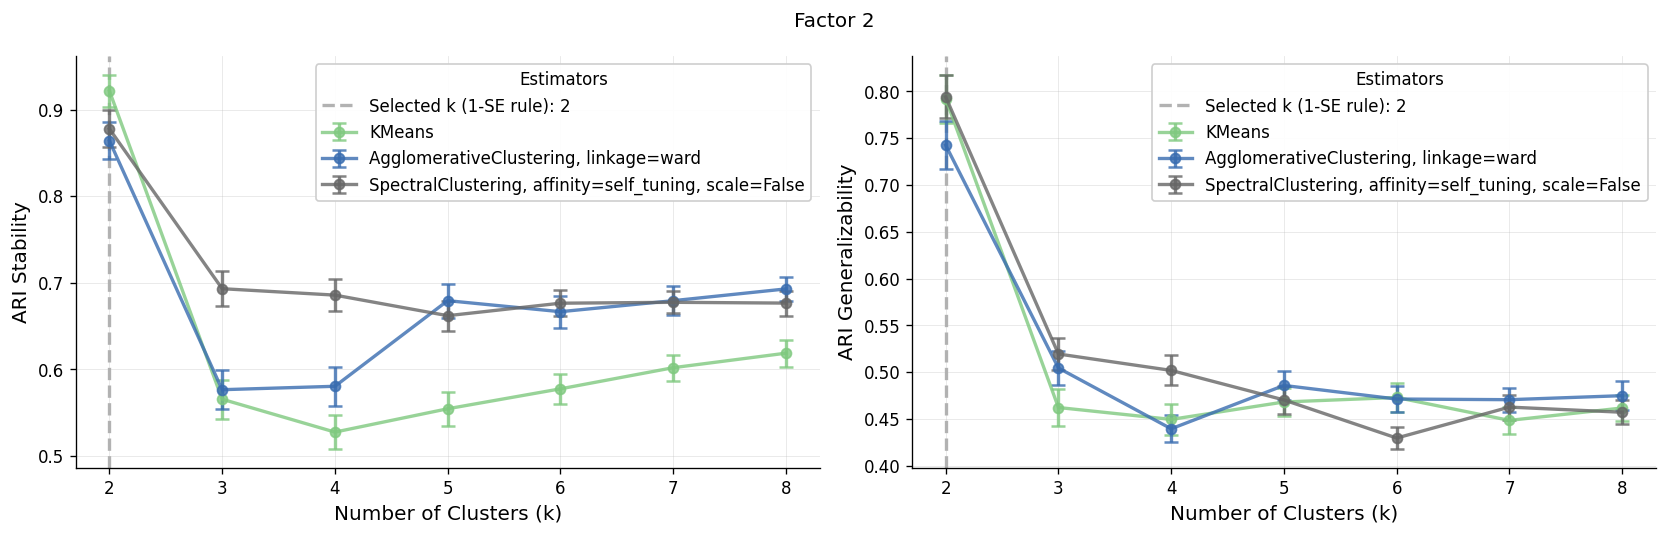

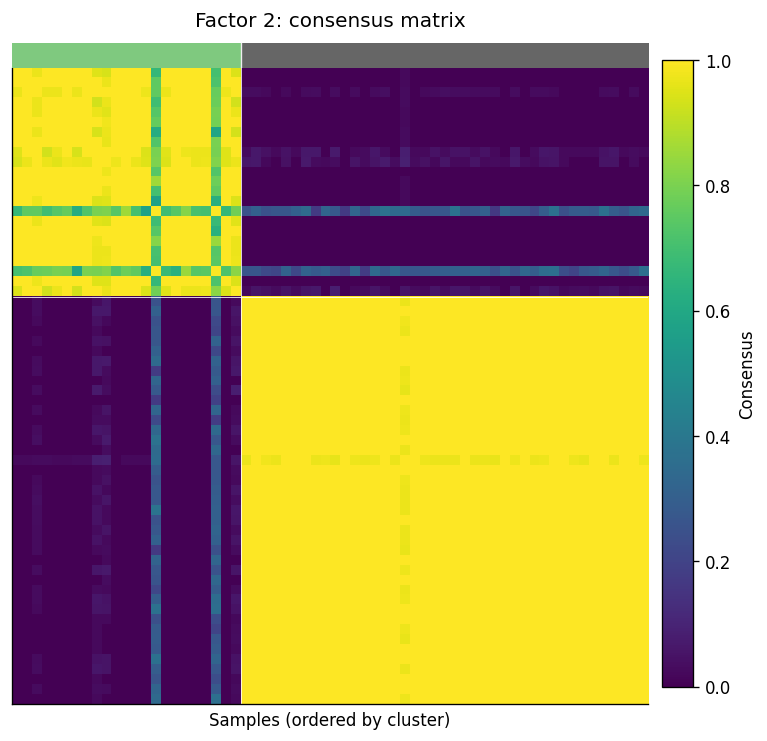

In [25]:
plot_carve_diagnostics(carve_f2, "Factor 2")

Cluster membership: entry $(\ell, t) =$ cluster of $\boldsymbol{\phi}_{\ell t 2}$.

In [26]:
labels_f2.add(1).unstack("treatment")

treatment,CVT-313,Control,Dinaciclib,PF-3600,Palbociclib,RO-3306,Samuraciclib,Talazoparib
cell_line,,,,,,,,
134,2,2,2,1,1,2,2,2
231,2,1,2,1,1,1,2,2
44PE,2,2,2,1,1,2,1,2
453,2,2,2,1,1,1,2,2
BCK4,2,2,2,1,1,2,1,2
MCF10A,2,2,2,1,1,2,2,1
MCF7,2,2,2,1,2,2,1,1
T47D,2,2,2,1,2,2,2,1


Heatmap as in 5.1, rows $\mathbf{y}_{\ell t 2}$.

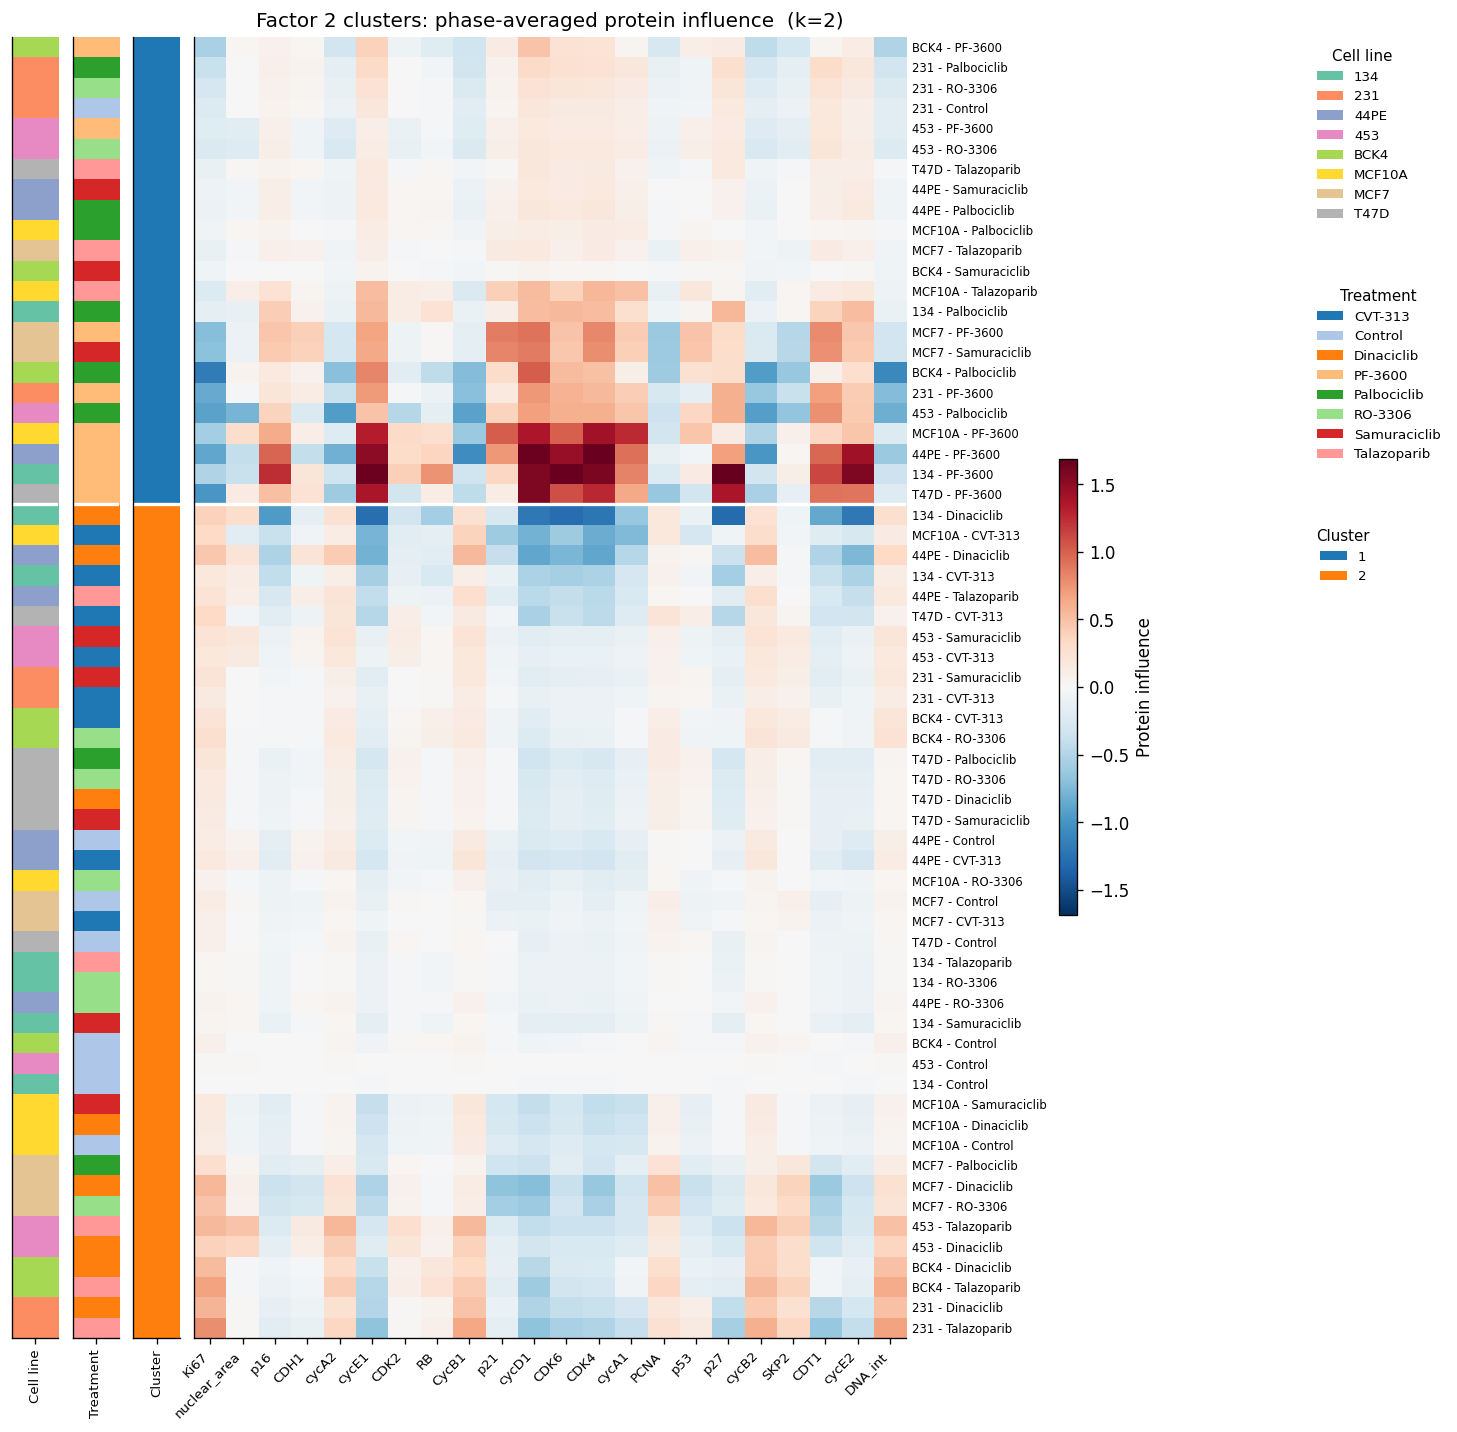

In [27]:
cross_cellline_cluster_heatmap(
    protein_factor_by_treatment_df.xs("Factor 2", level="factor"), labels_f2,
    title="Factor 2 clusters: phase-averaged protein influence",
);

Violins as in 5.1, clusters from $f = 2$.

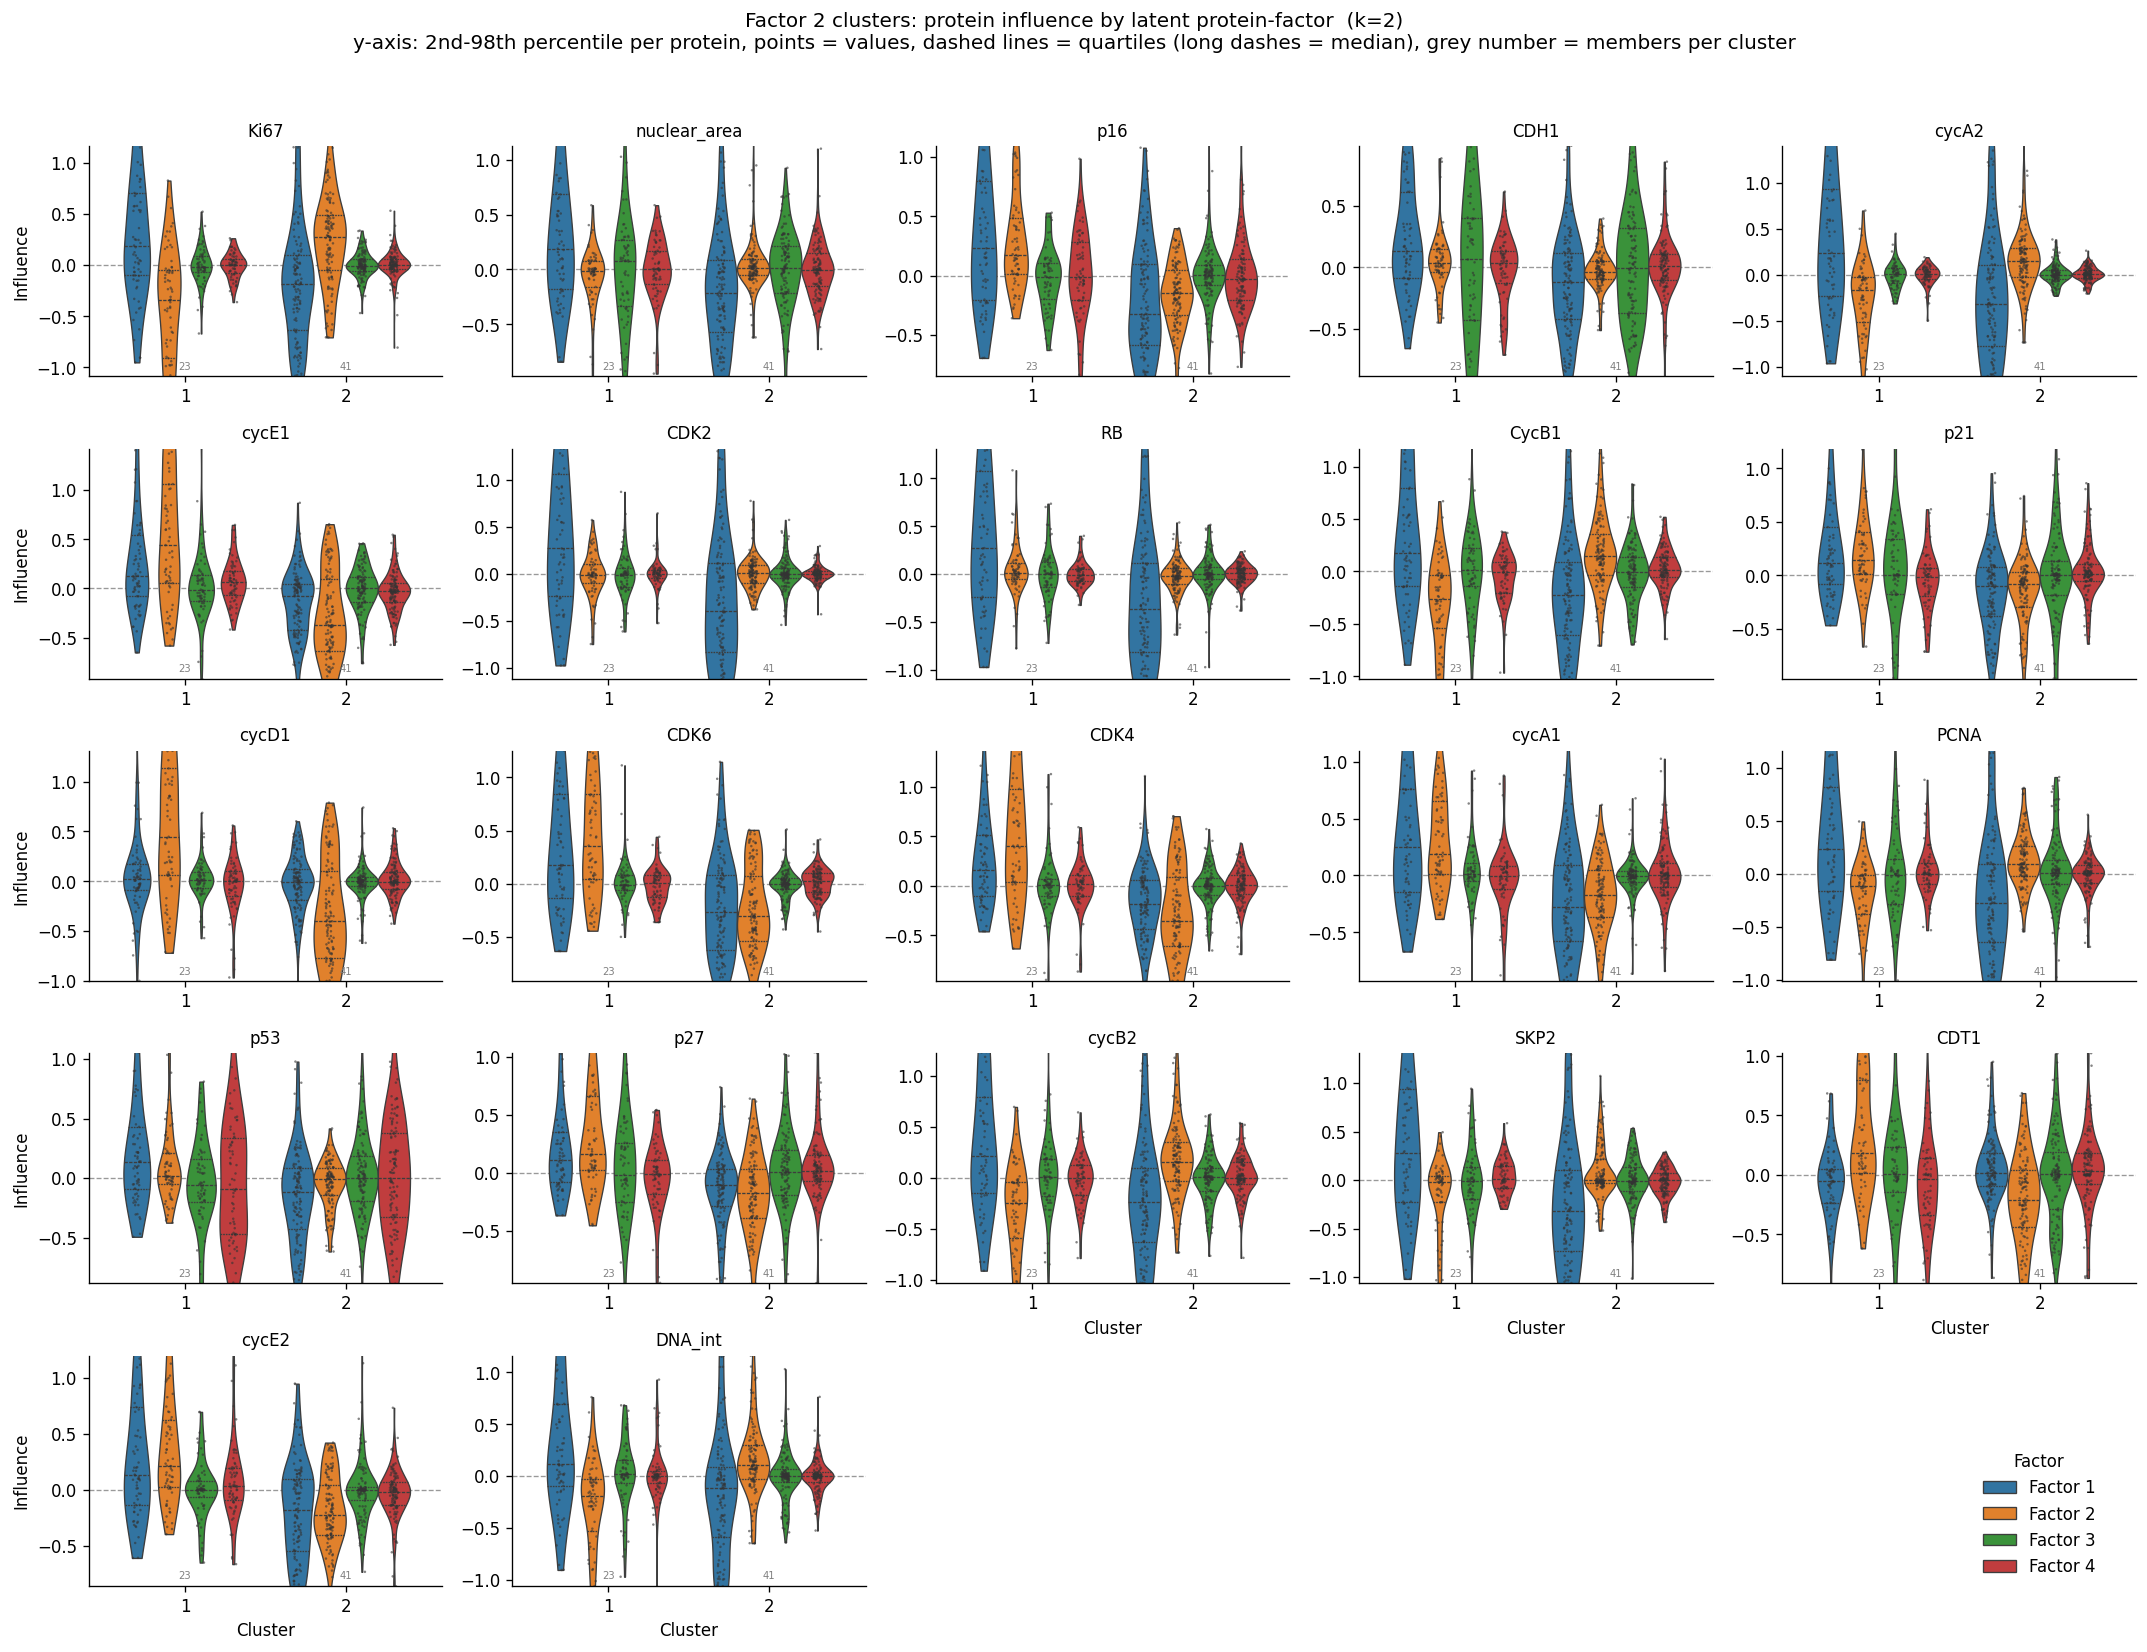

In [29]:
cross_cellline_cluster_violins(
    protein_influence_df, labels_f2,
    title="Factor 2 clusters: protein influence by latent protein-factor",
);

### 5.3 Factor 3:

As 5.1 with $f = 3$.

In [29]:
carve_f3, k_f3, labels_f3 = run_carve("Factor 3")

Factor 3: selected k = 5


Diagnostics for $f = 3$ (as in 5.1).

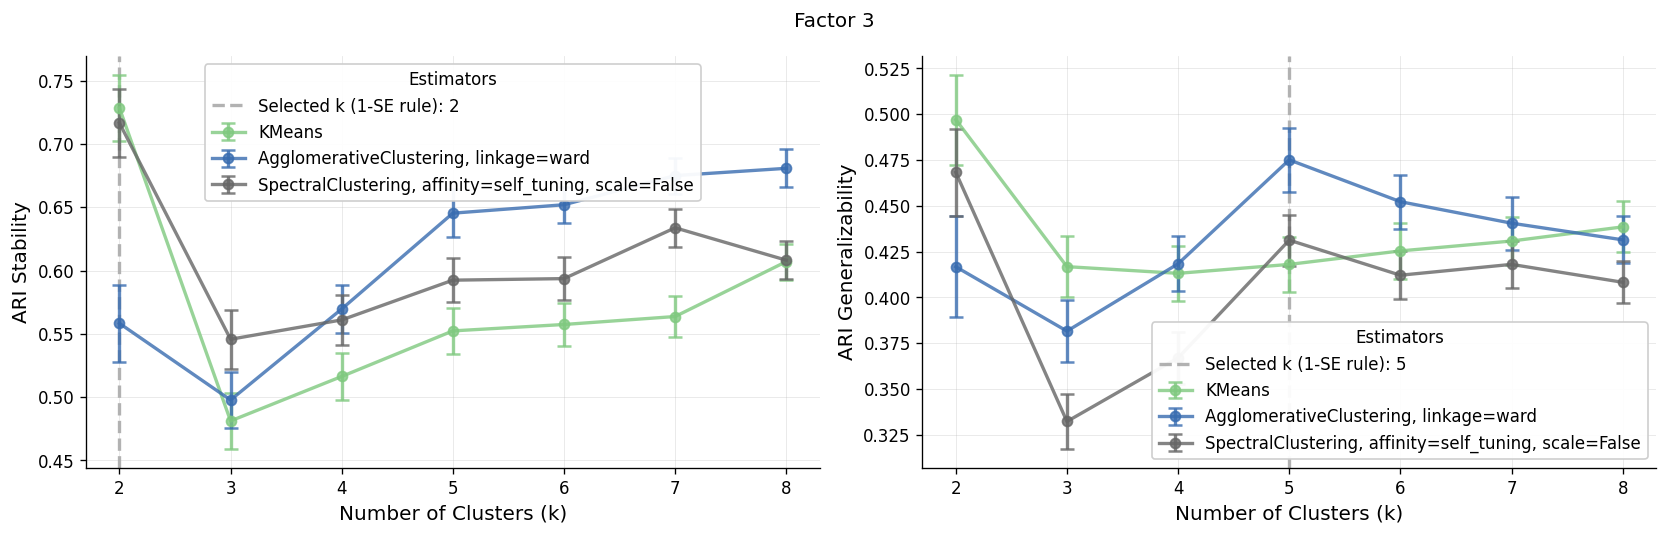

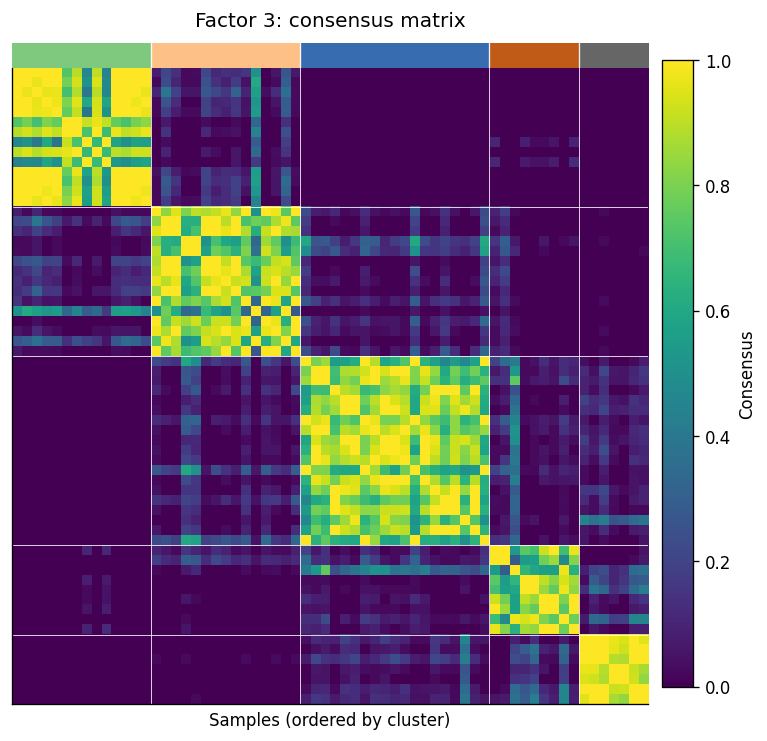

In [30]:
plot_carve_diagnostics(carve_f3, "Factor 3")

Cluster membership: entry $(\ell, t) =$ cluster of $\boldsymbol{\phi}_{\ell t 3}$.

In [31]:
labels_f3.add(1).unstack("treatment")

treatment,CVT-313,Control,Dinaciclib,PF-3600,Palbociclib,RO-3306,Samuraciclib,Talazoparib
cell_line,,,,,,,,
134,3,3,2,3,2,2,2,2
231,2,1,5,5,2,1,3,2
44PE,3,3,2,4,3,3,4,1
453,3,3,3,4,4,1,3,1
BCK4,2,3,3,5,2,2,2,3
MCF10A,1,1,5,4,1,1,5,1
MCF7,1,1,3,3,3,3,2,2
T47D,4,4,4,5,5,4,1,1


Heatmap as in 5.1, rows $\mathbf{y}_{\ell t 3}$.

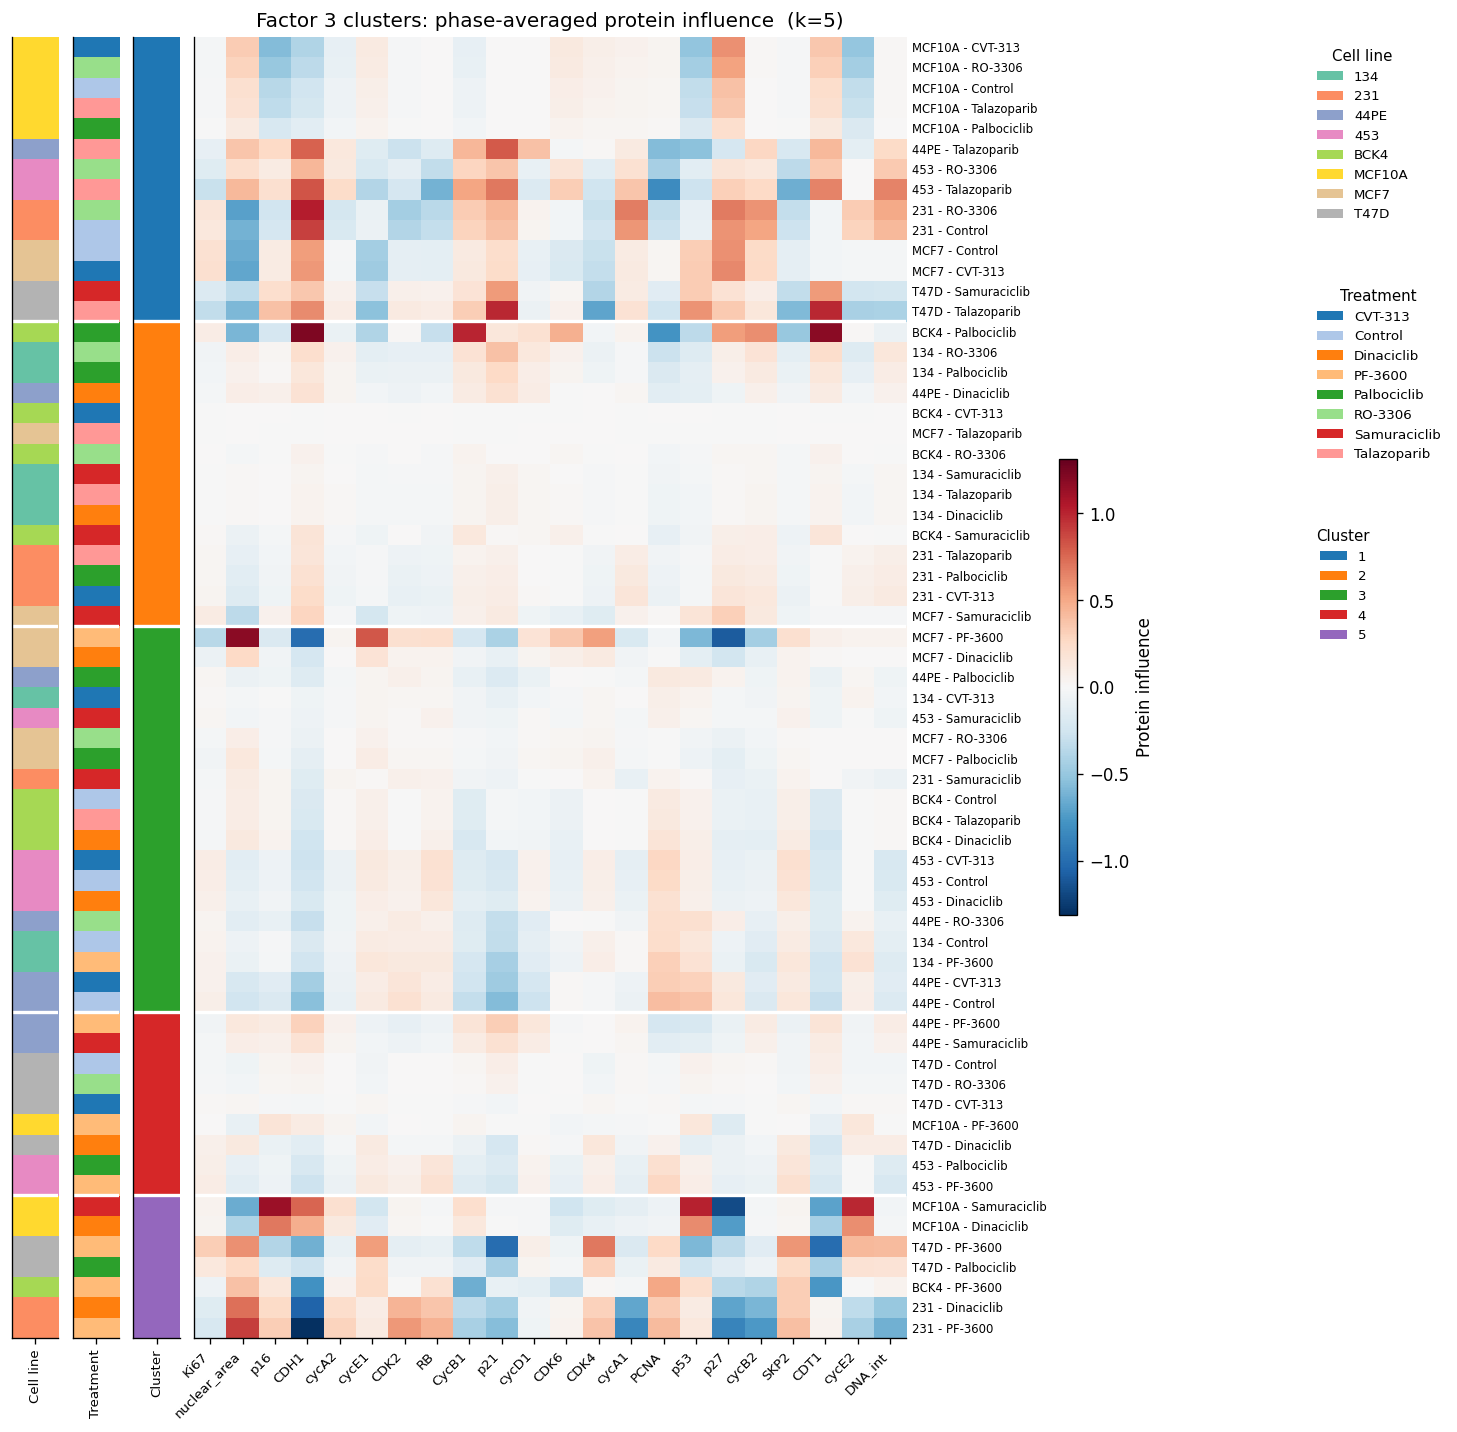

In [32]:
cross_cellline_cluster_heatmap(
    protein_factor_by_treatment_df.xs("Factor 3", level="factor"), labels_f3,
    title="Factor 3 clusters: phase-averaged protein influence",
);

### 5.4 Factor 4:

As 5.1 with $f = 4$.

In [33]:
carve_f4, k_f4, labels_f4 = run_carve("Factor 4")

Factor 4: selected k = 3


Diagnostics for $f = 4$ (as in 5.1).

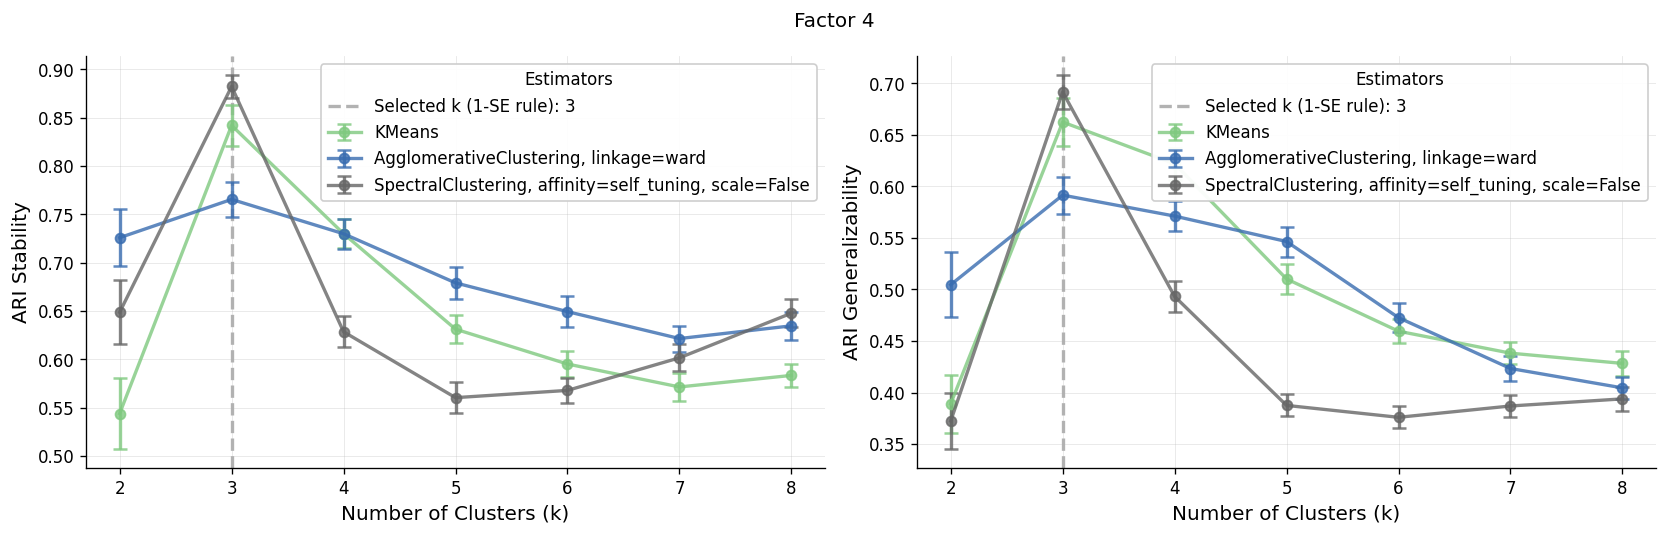

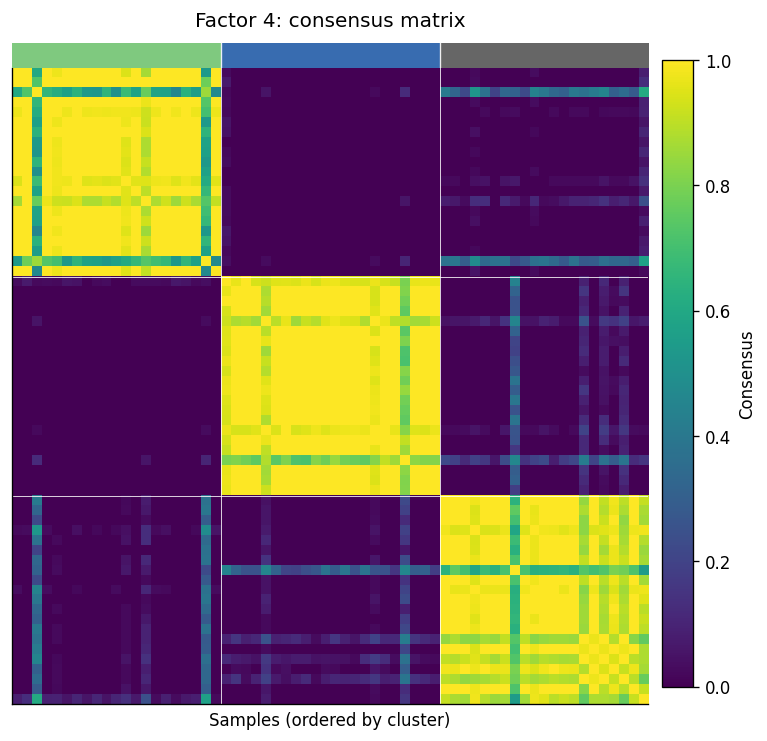

In [34]:
plot_carve_diagnostics(carve_f4, "Factor 4")

Cluster membership: entry $(\ell, t) =$ cluster of $\boldsymbol{\phi}_{\ell t 4}$.

In [35]:
labels_f4.add(1).unstack("treatment")

treatment,CVT-313,Control,Dinaciclib,PF-3600,Palbociclib,RO-3306,Samuraciclib,Talazoparib
cell_line,,,,,,,,
134,2,2,3,3,3,2,3,2
231,3,3,3,3,2,3,2,2
44PE,3,3,2,1,1,1,2,1
453,3,3,2,2,2,3,2,2
BCK4,3,3,3,3,1,3,2,2
MCF10A,1,1,1,1,2,2,2,2
MCF7,1,1,1,3,1,1,2,1
T47D,1,3,1,1,1,1,2,1


Heatmap as in 5.1, rows $\mathbf{y}_{\ell t 4}$.

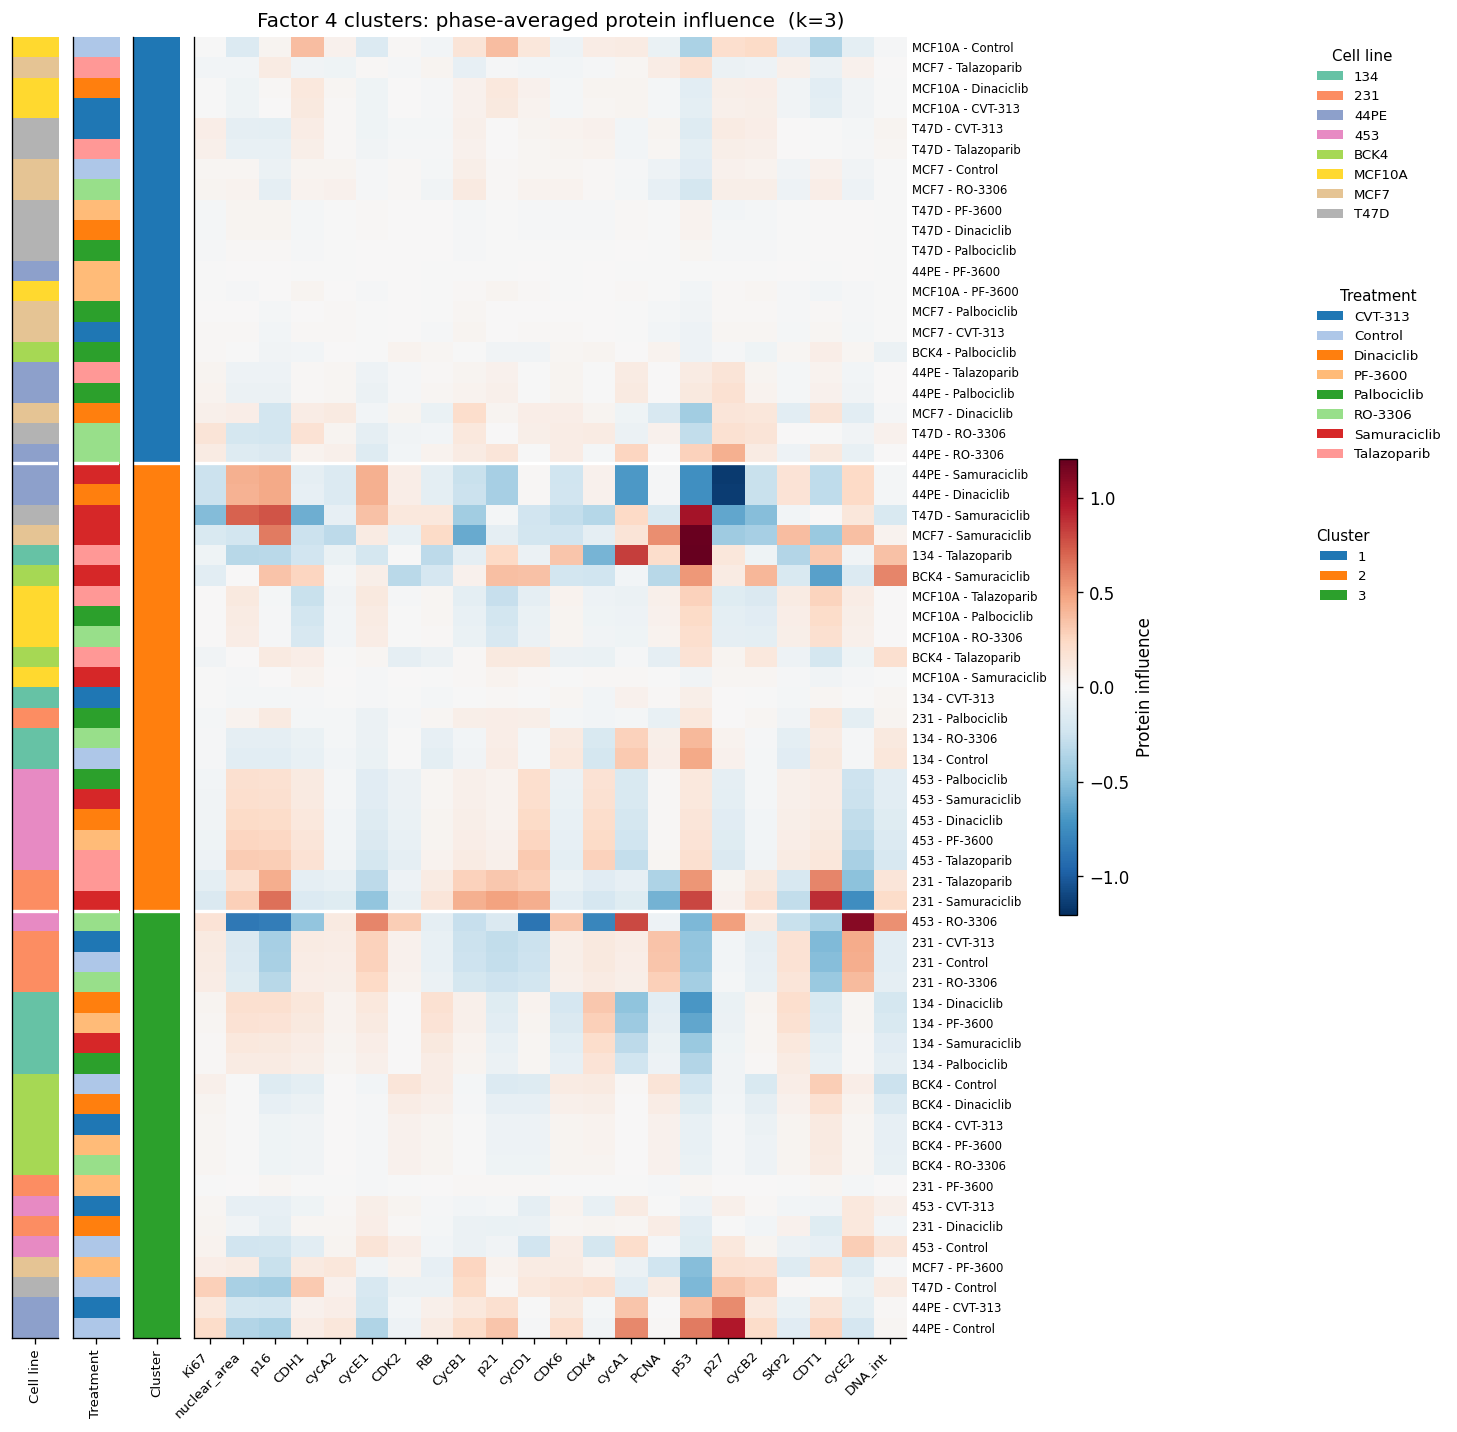

In [36]:
cross_cellline_cluster_heatmap(
    protein_factor_by_treatment_df.xs("Factor 4", level="factor"), labels_f4,
    title="Factor 4 clusters: phase-averaged protein influence",
);

## 6. Treatment factors across cell lines:

Each cell line's fit also re-expresses its 8 drugs as 8 treatment factors (weighted contrasts of the drugs); a treatment factor's signature is the matching weighted combination of the drugs' average protein profiles. The contrasts are defined separately in each line, so treatment factor $s$ in one line need not match treatment factor $s$ in another.

1. For each $\ell$: $\bar{\mathcal{G}}^{(\ell)} \leftarrow \frac{1}{c} \sum_j \big(\mathcal{G}^{(\ell)} \times_2 C^{(\ell)}\big)_{:,j,:} \in \mathbb{R}^{8 \times p_F}$ (row $s$ = treatment factor $s$).
2. For each $(\ell, s)$: row $\mathbf{w}_{\ell s} \leftarrow \bar{\mathcal{G}}^{(\ell)}_{s,:}\, P^{(\ell)\top} \in \mathbb{R}^{p}$.
3. $W \leftarrow$ all rows ($64 \times 22$).

Equivalently $\bar{\mathcal{G}}^{(\ell)} = T^{(\ell)\top} \bar{\mathcal{F}}^{(\ell)}$; the sign of $T^{(\ell)}_{:,s}$ is arbitrary.

In [37]:
treatment_factor_df = cross_cellline_treatment_factors(cct_dict)
print(f"Treatment factor matrix: {treatment_factor_df.shape}")
treatment_factor_df.head(8)

Treatment factor matrix: (64, 22)


Ki67  nuclear_area       p16      CDH1     cycA2  \
cell_line factor                                                           
134       Factor 1 -0.130824     -0.081364 -0.249966 -0.130548 -0.156210   
          Factor 2  0.186466      0.168969  2.089529  0.640307  0.358233   
          Factor 3 -0.628740     -0.237727  0.202305 -0.178456 -0.621109   
          Factor 4  0.068224      0.249941  0.143890  0.097569  0.050966   
          Factor 5  0.002498     -0.240221 -0.113637 -0.435091 -0.175241   
          Factor 6  0.136610      0.247597  0.116364  0.182068  0.160525   
          Factor 7 -0.055520     -0.118461 -0.061125 -0.124387 -0.087961   
          Factor 8 -0.016434      0.003605 -0.037034  0.044643  0.010910   

                       cycE1      CDK2        RB     CycB1       p21  ...  \
cell_line factor                                                      ...   
134       Factor 1 -0.227001 -0.260126 -0.254004 -0.134671 -0.165613  ...   
          Factor 2  2.364878  1.391382  1.824926  0.189472  0.474692  ...   
          Factor 3  0.485323 -0.509150 -0.050765 -0.587280 -0.628220  ...   
          Factor 4  0.075880 -0.017889  0.196563  0.043370 -0.318714  ...   
          Factor 5  0.187973  0.117768  0.083957 -0.393437 -0.616733  ...   
          Factor 6 -0.023081  0.056696  0.145737  0.190292  0.003184  ...   
          Factor 7  0.028288 -0.017988 -0.046973 -0.125603 -0.095809  ...   
          Factor 8 -0.080377 -0.046394 -0.071754  0.050159  0.123759  ...   

                        CDK4     cycA1      PCNA       p53       p27  \
cell_line factor                                                       
134       Factor 1 -0.199370 -0.339522 -0.159460 -0.270923 -0.209624   
          Factor 2  2.374357  1.453963  0.516344  0.552172  1.952386   
          Factor 3  0.771632 -1.171533 -0.670815 -1.587432  0.207600   
          Factor 4  0.333112 -0.713513 -0.094204 -0.907308 -0.243815   
          Factor 5  0.043732  0.114224  0.429525  0.418433 -0.085695   
          Factor 6  0.134236 -0.307919 -0.042415 -0.447525 -0.148174   
          Factor 7 -0.038539  0.091266  0.058398  0.176184  0.030732   
          Factor 8 -0.086402  0.032018 -0.071772  0.020718  0.007695   

                       cycB2      SKP2      CDT1     cycE2   DNA_int  
cell_line factor                                                      
134       Factor 1 -0.150519 -0.179073 -0.116124 -0.299428 -0.181590  
          Factor 2  0.245663  1.078167  0.949746  2.501433  0.108400  
          Factor 3 -0.659598 -0.162036 -0.024275  0.100796 -1.076205  
          Factor 4 -0.000564  0.278384 -0.373193 -0.046847 -0.303738  
          Factor 5 -0.360846  0.094786 -0.291267  0.247291 -0.257821  
          Factor 6  0.166005  0.203589 -0.174846 -0.059153  0.003008  
          Factor 7 -0.114637 -0.062551  0.013521  0.041444 -0.052832  
          Factor 8  0.048666 -0.070030  0.073422 -0.080342  0.068318  

[8 rows x 22 columns]

### 6.1 PCA:

Each point is one treatment factor from one cell line, placed so that similar protein signatures sit close together.

1. $Z \leftarrow \mathrm{PCA}_2(W)$.
2. Scatter $Z$, one point per $(\ell, s)$: color $= s$, marker $= \ell$.

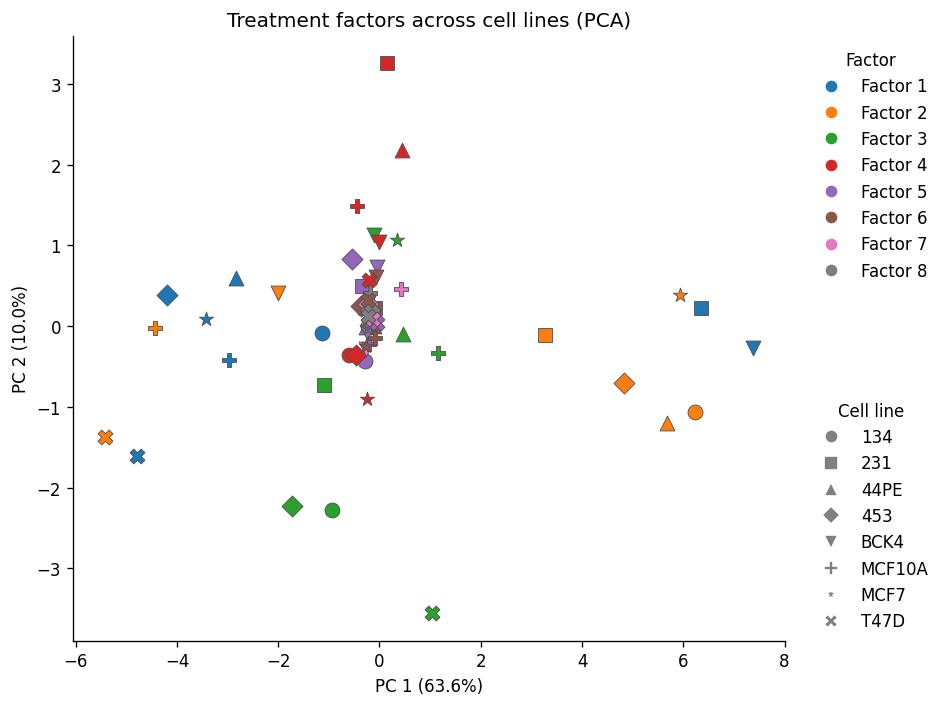

In [38]:
cross_cellline_embedding(
    treatment_factor_df, method="pca",
    title="Treatment factors across cell lines (PCA)"
);

### 6.2 t-SNE:

The same comparison with a nonlinear map that emphasizes local groups.

As 6.1 with $Z \leftarrow \mathrm{tSNE}_2(W)$.

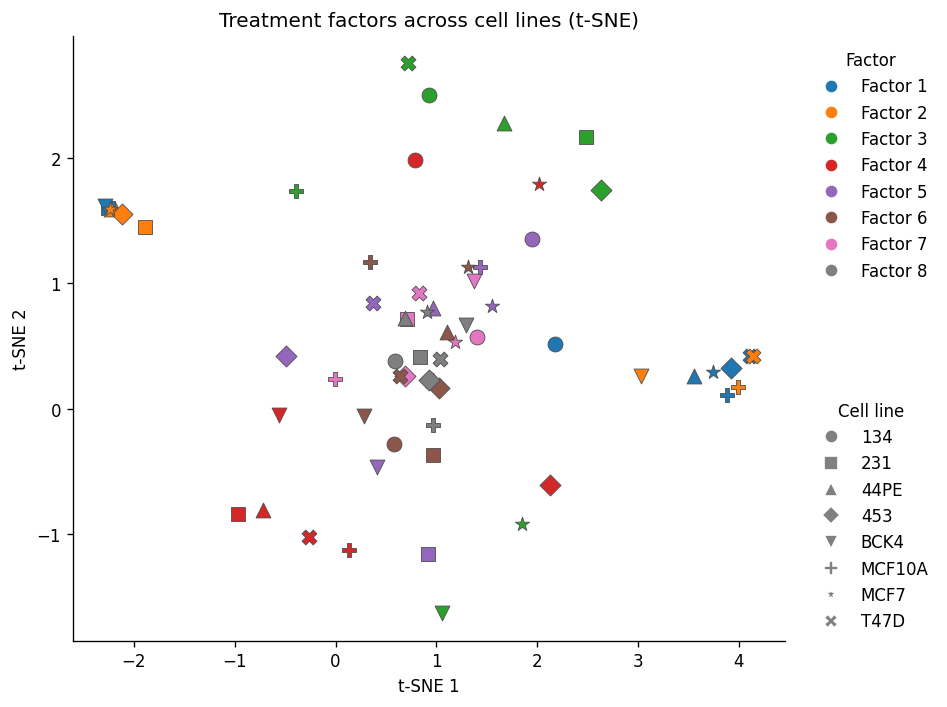

In [39]:
cross_cellline_embedding(
    treatment_factor_df, method="tsne",
    title="Treatment factors across cell lines (t-SNE)"
);

### 6.3 UMAP:

The same comparison with UMAP; tight groups are meaningful, distances between groups are not.

As 6.1 with $Z \leftarrow \mathrm{UMAP}_2(W)$.

/Users/kaiwycik/.pyenv/versions/3.13.3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


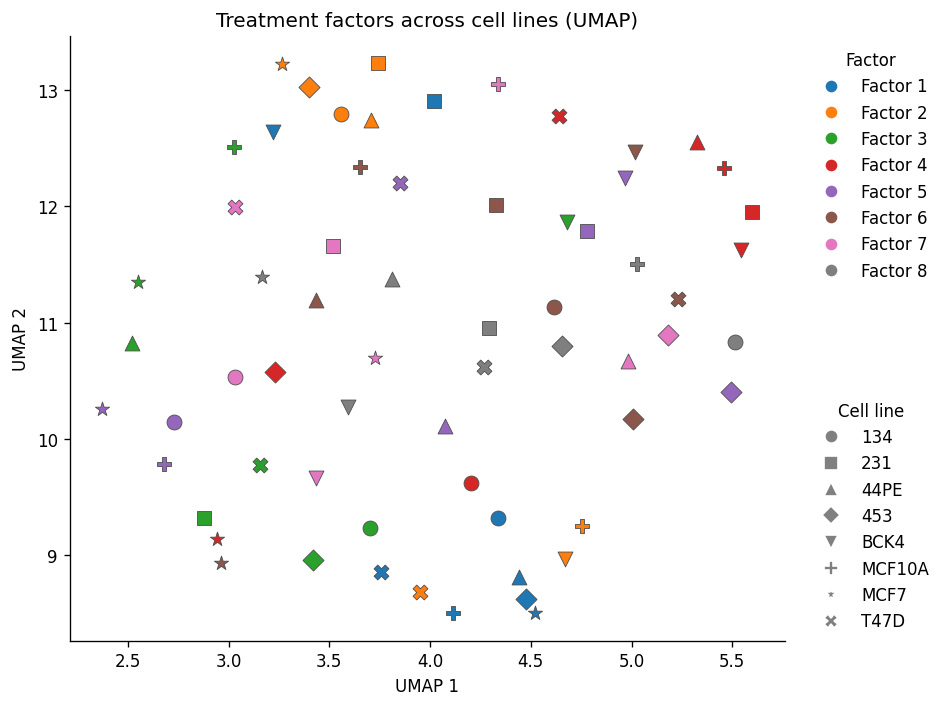

In [40]:
cross_cellline_embedding(
    treatment_factor_df, method="umap",
    title="Treatment factors across cell lines (UMAP)"
);

### 6.4 Cosine-similarity clustermap:

Similarity of the treatment-factor signatures, as in 2.3. The sign of a treatment factor is arbitrary, so a strongly negative similarity (blue) indicates the same signature as a strongly positive one (red).

As 2.3 on the rows of $W$; side bars: cell line, treatment factor $s$.

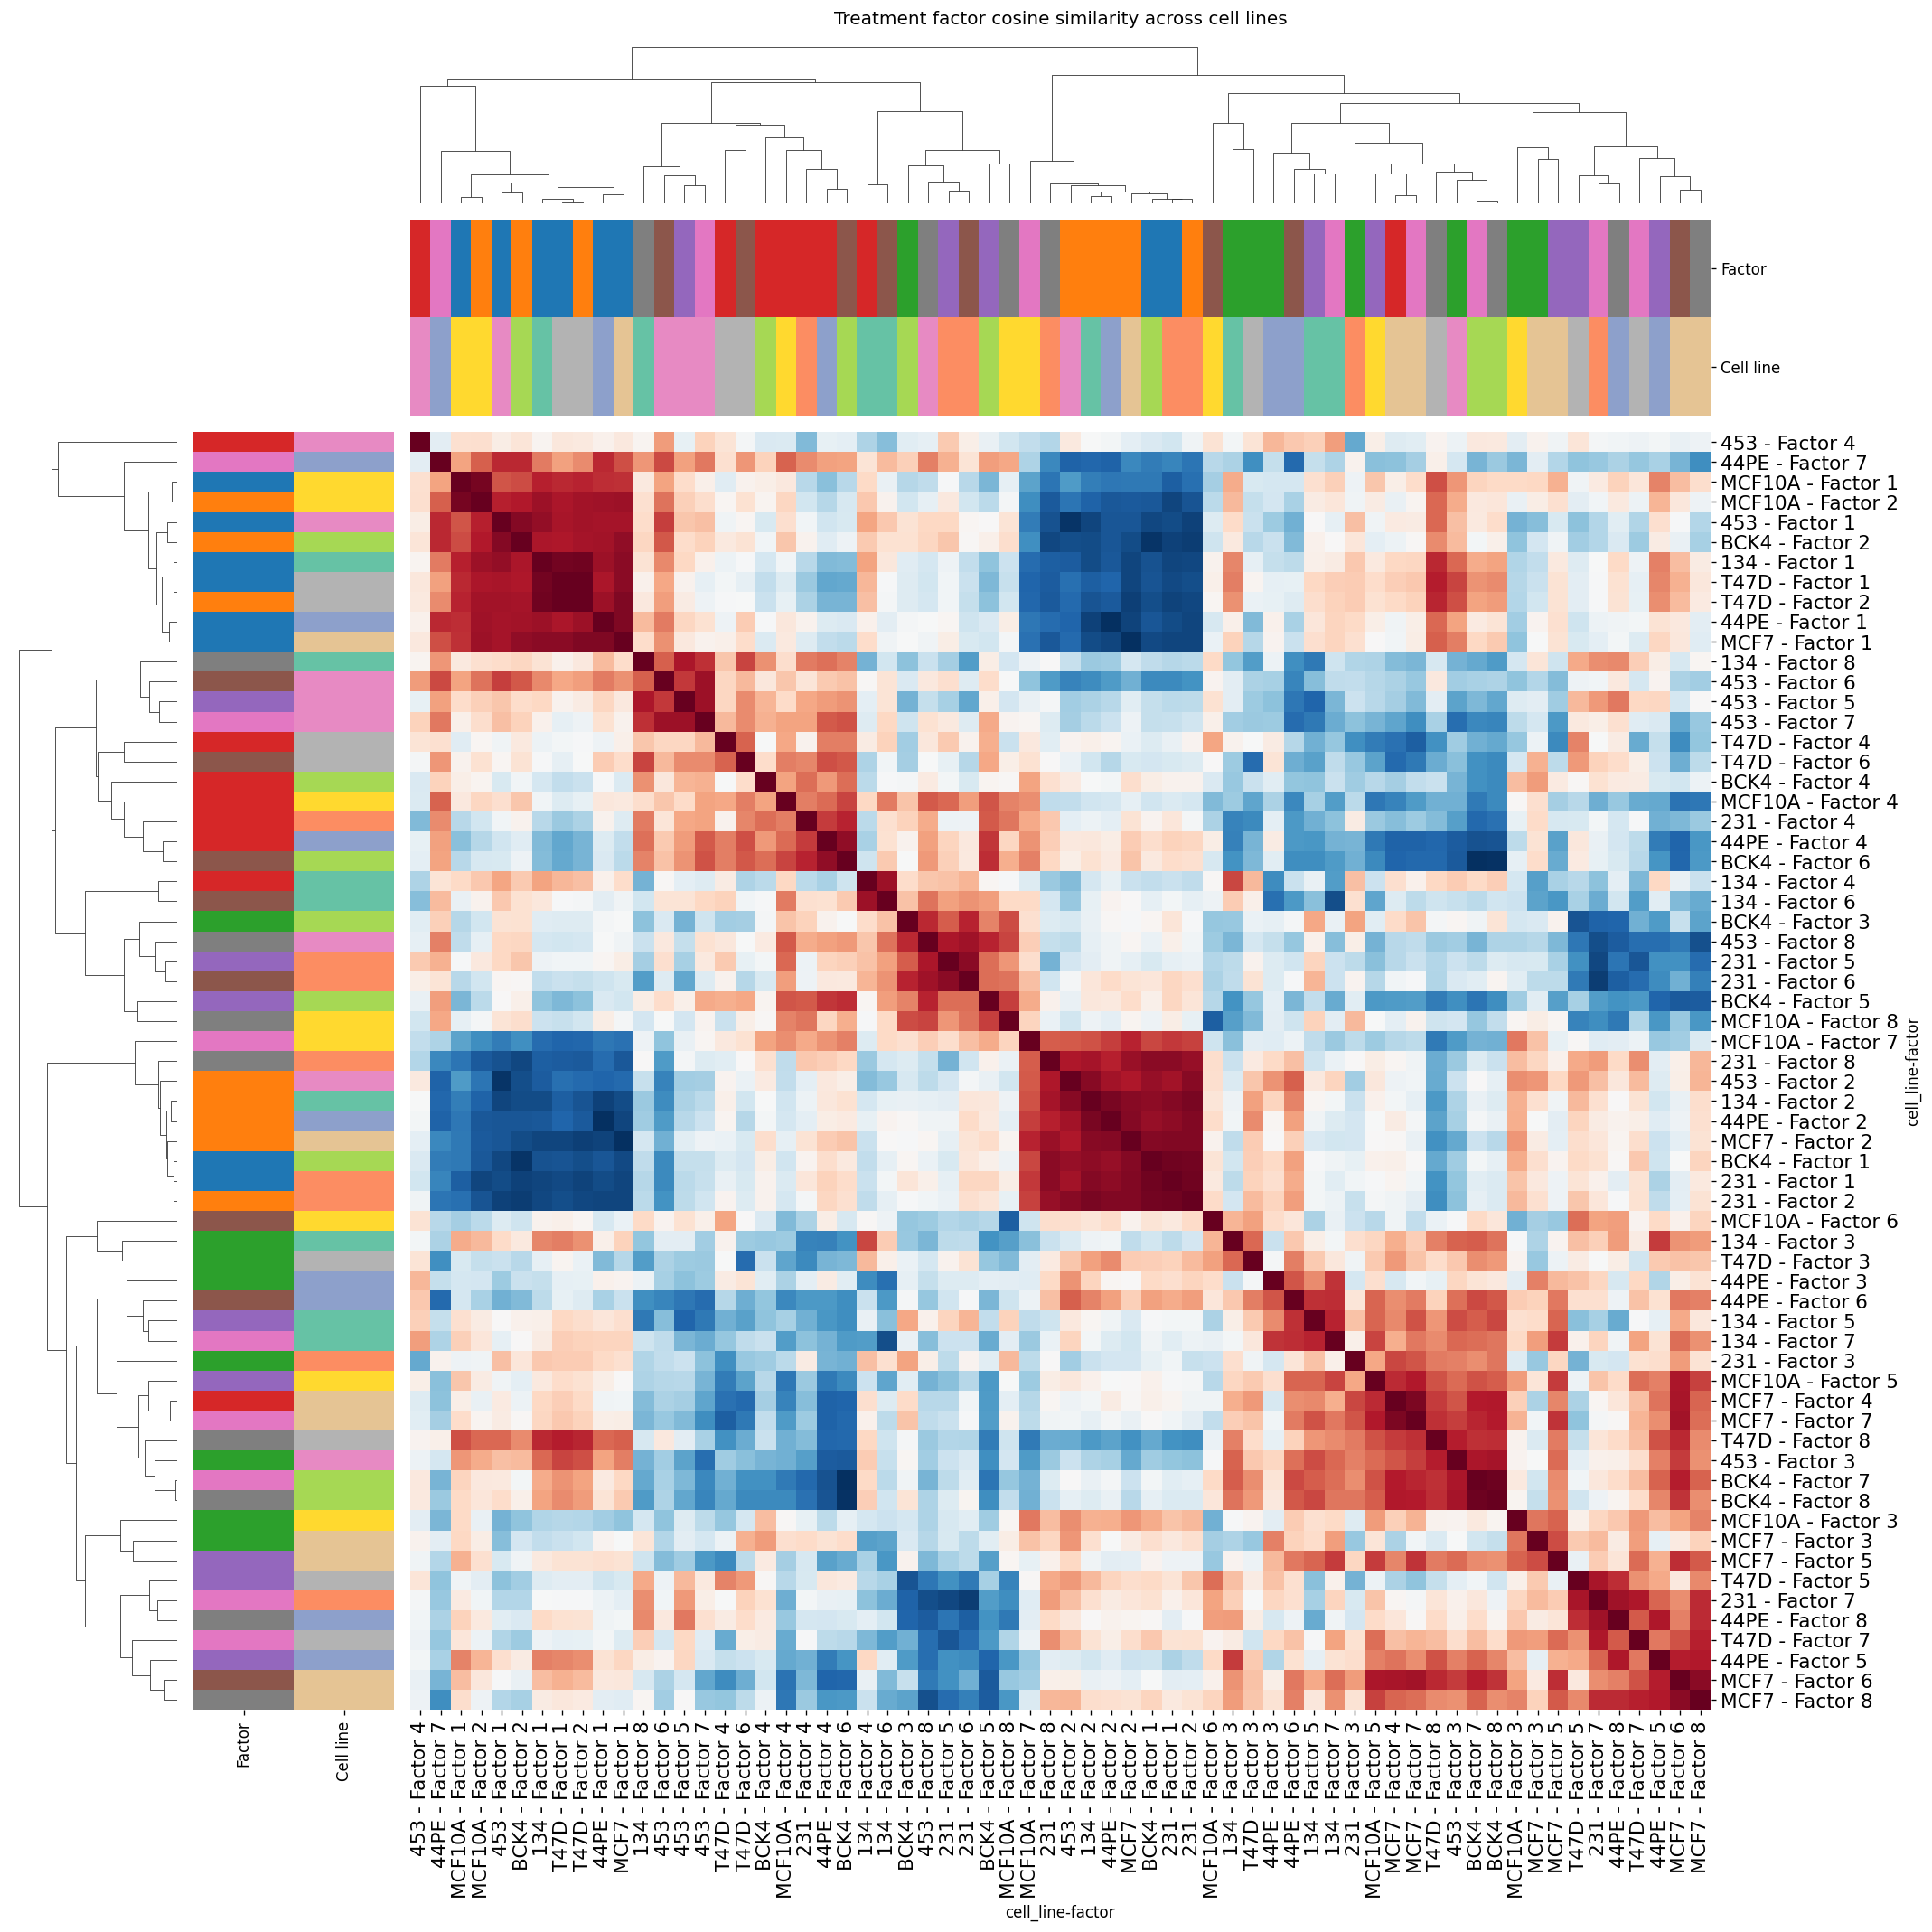

In [41]:
cross_cellline_clustermap(
    treatment_factor_df, annotate=False,
    title="Treatment factor cosine similarity across cell lines"
);

---